# Comparison of the identified models

Least squares (Forward, Backward), PySINDy (STLSQ, FROLS, SSR) and PySR, all fitted on the training levels (500, 1000, 2000 and 2500 mg) and tested on the 1500 mg level. The saved results are checked for identical data and settings before the comparison.

## Imports


In [11]:
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "notebooks" / "pipeline").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Project root could not be located.")
    PROJECT_ROOT = PROJECT_ROOT.parent

COLORS = {"purple": "#5E3C99", "orange": "#D55E00", "green": "#009E73",
          "blue": "#0072B2", "brown": "#8C564B", "yellow": "#E69F00"}
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 13,
    "lines.linewidth": 1.5,
    "axes.xmargin": 0.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "path.simplify": True,
    "agg.path.chunksize": 10000,
    "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
})


def slug(name):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name)).strip("_").lower()

In [2]:
# Shared protocol: TEST_LEVEL_MG (both sweeps) is the test set; the other levels train.
# Predictions are made at the measured states; NRMSE = RMSE / std(measured).
LEVELS_MG = (500, 1000, 1500, 2000, 2500)
TEST_LEVEL_MG = 1500
TRAINING_LEVELS_MG = tuple(level for level in LEVELS_MG if level != TEST_LEVEL_MG)
ROLES = ("train", "test")
PROTOCOL_DESCRIPTION = (f"single train/test split: test level {TEST_LEVEL_MG} mg; "
                        f"training levels {TRAINING_LEVELS_MG} mg")
SWEEP_MIN_HZ, SWEEP_MAX_HZ = 50.0, 150.0
RESONANCE_BAND_HZ = (80.0, 110.0)
# Selection score on the training set: TOTAL_ERROR_WEIGHT * NRMSE
# + RESONANCE_ERROR_WEIGHT * resonance-band NRMSE. The smallest model within
# ACCEPTABLE_ERROR_INCREASE of the best score is selected.
TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT = 0.3, 0.7
ACCEPTABLE_ERROR_INCREASE = 0.1


def excitation_level_mg(name):
    return int(re.search(r"(\d+)mg", str(name)).group(1))


def sweep_direction(name):
    return "down" if "sweep_down" in str(name) else "up"


def sweep_frequency_hz(name, t):
    """Nominal frequency, assuming a linear sweep."""
    fraction = (t - t[0]) / (t[-1] - t[0])
    if sweep_direction(name) == "down":
        return SWEEP_MAX_HZ - fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)
    return SWEEP_MIN_HZ + fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)


def resonance_band_mask(name, t):
    """Samples whose nominal sweep frequency lies in the resonance band."""
    frequency = sweep_frequency_hz(name, t)
    return (frequency >= RESONANCE_BAND_HZ[0]) & (frequency <= RESONANCE_BAND_HZ[1])


def signal_role(name):
    """Split role of an experiment: 'test' at the test level, 'train' otherwise."""
    return "test" if excitation_level_mg(name) == TEST_LEVEL_MG else "train"


def check_signals(signals, require_all_levels=True):
    names = [s["name"] for s in signals]
    if len(set(names)) != len(names):
        raise ValueError("Signal names must be unique.")
    found = {}
    for signal in signals:
        level = excitation_level_mg(signal["name"])
        if level not in LEVELS_MG:
            raise ValueError(f"Unknown excitation level: {signal['name']}")
        found.setdefault(level, []).append(sweep_direction(signal["name"]))
        arrays = [np.asarray(signal[k], dtype=float).reshape(-1) for k in ("t", "x", "v", "u", "v_dot")]
        if len({len(a) for a in arrays}) != 1 or len(arrays[0]) < 2:
            raise ValueError(f"Mismatched array lengths: {signal['name']}")
        if not all(np.isfinite(a).all() for a in arrays):
            raise ValueError(f"Nonfinite data: {signal['name']}")
        if np.any(np.diff(arrays[0]) <= 0):
            raise ValueError(f"Time must increase: {signal['name']}")
    for level in (LEVELS_MG if require_all_levels else found):
        if sorted(found.get(level, [])) != ["down", "up"]:
            raise ValueError(f"Level {level} mg needs exactly one upward and one downward sweep.")
    return sorted(signals, key=lambda s: (excitation_level_mg(s["name"]), s["name"]))


def split_signals(signals):
    """Single train/test split by excitation level."""
    signals = check_signals(signals)
    return {"test_level_mg": TEST_LEVEL_MG, "fit_levels_mg": TRAINING_LEVELS_MG,
            "fit": [s for s in signals if signal_role(s["name"]) == "train"],
            "test": [s for s in signals if signal_role(s["name"]) == "test"]}


def split_table(split):
    rows = []
    for role, key, levels in (("train", "fit", split["fit_levels_mg"]),
                              ("test", "test", (split["test_level_mg"],))):
        rows.append({"role": role, "levels_mg": tuple(levels), "experiments": len(split[key]),
                     "samples": sum(len(s["t"]) for s in split[key])})
    return pd.DataFrame(rows)


def scores(measured, predicted, resonance_mask, weights):
    residual = measured - predicted
    rmse = np.sqrt(np.mean(residual ** 2))
    nrmse = rmse / np.std(measured)
    r2 = 1.0 - np.sum(residual ** 2) / np.sum((measured - np.mean(measured)) ** 2)
    resonance = (np.sqrt(np.mean(residual[resonance_mask] ** 2))
                 / np.std(measured[resonance_mask]))
    return {"total_RMSE": rmse, "total_NRMSE": nrmse, "total_R2": r2,
            "resonance_NRMSE": resonance,
            "weighted_score": weights[0] * nrmse + weights[1] * resonance}


def build_series(signals):
    series = {}
    for signal in check_signals(signals, require_all_levels=False):
        name = signal["name"]
        t, x, v, u, measured = (np.asarray(signal[k], dtype=float).reshape(-1)
                                for k in ("t", "x", "v", "u", "v_dot"))
        series[name] = {
            "level_mg": excitation_level_mg(name), "sweep": sweep_direction(name),
            "role": signal_role(name),
            "time": t - t[0], "x": x, "v": v, "input": u,
            "experimental_acceleration": measured,
            "instantaneous_frequency_hz": sweep_frequency_hz(name, t),
            "resonance_mask": resonance_band_mask(name, t),
            "model_predictions": {},
        }
    return series


def add_predictions(series, model_functions, names=None):
    """Store each model's predictions under the role of each experiment (or only `names`)."""
    for name, record in series.items():
        if names is not None and name not in names:
            continue
        x, v, u = record["x"], record["v"], record["input"]
        for model_name, function in model_functions.items():
            predicted = np.broadcast_to(np.asarray(function(x, v, u), dtype=float),
                                        record["experimental_acceleration"].shape).astype(float)
            if not np.isfinite(predicted).all():
                raise ValueError(f"Nonfinite prediction: {model_name} on {name}")
            record["model_predictions"].setdefault(model_name, {})[record["role"]] = predicted
    return series


def summarize_models(series, weights=(TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT)):
    """Metric tables per signal, per level and per role (train/test, pooled)."""
    per_signal, models = [], []
    for name, record in series.items():
        for model, roles in record["model_predictions"].items():
            if model not in models:
                models.append(model)
            for role, predicted in roles.items():
                per_signal.append({
                    "signal": name, "level_mg": record["level_mg"], "sweep": record["sweep"],
                    "model": model, "role": role,
                    **scores(record["experimental_acceleration"], predicted,
                             record["resonance_mask"], weights)})
    per_level, aggregate = [], []
    for model in models:
        names = [n for n, r in series.items() if model in r["model_predictions"]]

        def pooled(group):
            measured = np.concatenate([series[n]["experimental_acceleration"] for n in group])
            mask = np.concatenate([series[n]["resonance_mask"] for n in group])
            predicted = np.concatenate([series[n]["model_predictions"][model][series[n]["role"]]
                                        for n in group])
            return {"signals": len(group), "samples": len(measured),
                    **scores(measured, predicted, mask, weights)}

        for level in sorted({series[n]["level_mg"] for n in names}):
            group = [n for n in names if series[n]["level_mg"] == level]
            per_level.append({"level_mg": level, "role": series[group[0]]["role"],
                              "model": model, **pooled(group)})
        for role in ROLES:
            group = [n for n in names if series[n]["role"] == role]
            if group:
                aggregate.append({"model": model, "role": role,
                                  "levels_mg": tuple(sorted({series[n]["level_mg"] for n in group})),
                                  **pooled(group)})
    return (pd.DataFrame(per_signal), pd.DataFrame(per_level), pd.DataFrame(aggregate))


def regression_block(library, target, resonance_mask):
    """Library, target and resonance mask of one experiment (all samples)."""
    library = np.asarray(library, dtype=float)
    target = np.asarray(target, dtype=float).reshape(-1)
    resonance_mask = np.asarray(resonance_mask, dtype=bool).reshape(-1)
    if library.shape[0] != len(target) or len(resonance_mask) != len(target):
        raise ValueError("Library, target and resonance mask must have the same number of samples.")
    return {"Theta": library, "y": target, "resonance_mask": resonance_mask, "samples": len(target)}


def coefficient_scores(theta, blocks):
    """Pooled NRMSE, resonance-band NRMSE and selection score of a coefficient vector."""
    residual = np.concatenate([b["y"] - b["Theta"] @ theta for b in blocks])
    measured = np.concatenate([b["y"] for b in blocks])
    mask = np.concatenate([b["resonance_mask"] for b in blocks])
    total = np.sqrt(np.mean(residual ** 2)) / np.std(measured)
    resonance = np.sqrt(np.mean(residual[mask] ** 2)) / np.std(measured[mask])
    return {"nrmse": total, "resonance_nrmse": resonance,
            "score": TOTAL_ERROR_WEIGHT * total + RESONANCE_ERROR_WEIGHT * resonance}


def within_tolerance(results, score_column="training_score"):
    """Rows whose score is within ACCEPTABLE_ERROR_INCREASE of the best finite score."""
    finite = results[np.isfinite(results[score_column])]
    limit = finite[score_column].min() * (1.0 + ACCEPTABLE_ERROR_INCREASE) + 1e-14
    return finite[finite[score_column] <= limit]


In [3]:
# Line styles: solid = test, dashed = train.
ROLE_STYLES = {"train": "--", "test": "-"}
ROLE_LABELS = {"train": "Train", "test": "Test"}


def plot_diagnostics(series, folder, roles=ROLES, names=None):
    """Diagnostic figures; `roles` and `names` restrict the plotted predictions and signals."""
    scales = {}
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    for name, record in series.items():
        if names is not None and name not in names:
            continue
        label = f"{record['level_mg']} mg, sweep {record['sweep']}"
        time, x, v, u = record["time"], record["x"], record["v"], record["input"]
        measured, mask = record["experimental_acceleration"], record["resonance_mask"]
        predictions = [(model, role, predicted)
                       for model, model_roles in record["model_predictions"].items()
                       for role, predicted in model_roles.items() if role in roles]
        tip = measured + u
        x_scale, v_scale, tip_scale = (max(np.max(np.abs(a)), np.finfo(float).eps)
                                       for a in (x, v, tip))
        scales[name] = {"x_scale": x_scale, "v_scale": v_scale, "a_tip_scale": tip_scale,
                        "level_mg": record["level_mg"], "comparison_points": len(x),
                        "normalization": "maximum absolute experimental value"}

        for window, tag in [(slice(None), "time"), (mask, "resonance")]:
            fig, ax = plt.subplots()
            ax.plot(time[window], measured[window], color="k", lw=1.0,
                    label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.plot(time[window], predicted[window], ROLE_STYLES[role], lw=0.4,
                        alpha=0.55, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel("Time [s]")
            ax.set_ylabel("Relative acceleration [m/s$^2$]")
            ax.legend(loc="upper right")
            fig.savefig(folder / f"one_step_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)

        fig, ax = plt.subplots()
        for model, role, predicted in predictions:
            ax.scatter(measured, predicted, s=2, alpha=0.2, rasterized=True,
                       label=f"{model} ({ROLE_LABELS[role]})")
        limits = [float(measured.min()), float(measured.max())]
        ax.plot(limits, limits, "k--", lw=1.0, label=f"Ideal - {label}")
        ax.set_xlabel("Measured $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.set_ylabel("Predicted $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.legend(loc="upper left")
        fig.savefig(folder / f"one_step_parity_{slug(name)}.pdf", format="pdf")
        plt.show()
        plt.close(fig)

        cuts = [(v, v_scale, np.abs(x / x_scale) <= 1e-3, "velocity, $v^*$", "velocity"),
                (x, x_scale, np.abs(v / v_scale) <= 1e-3, "displacement, $x^*$", "displacement")]
        for axis, scale, cut, axis_label, tag in cuts:
            fig, ax = plt.subplots()
            ax.scatter(axis[cut] / scale, tip[cut] / tip_scale, s=9, color="k",
                       rasterized=True, label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.scatter(axis[cut] / scale, (predicted + u)[cut] / tip_scale, s=7,
                           alpha=0.5, rasterized=True, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel(f"Dimensionless {axis_label}")
            ax.set_ylabel("Dimensionless tip acceleration, $a_{\\mathrm{tip}}^*$")
            ax.legend(loc="upper left")
            fig.savefig(folder / f"dimensionless_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)
    return scales


def plot_level_metrics(per_level, metric, ylabel, filename):
    table = per_level.assign(label=per_level["model"] + " (" + per_level["role"].map(ROLE_LABELS) + ")")
    table = table.pivot(index="level_mg", columns="label", values=metric)
    fig, ax = plt.subplots()
    table.plot.bar(ax=ax)
    ax.set(xlabel="Excitation level [mg]", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7)
    fig.savefig(filename)
    plt.show()
    plt.close(fig)
    return table

## Load saved results


In [4]:
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "pipeline" / "6_model_comparison"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LEAST_SQUARES_RESULTS_FILE = RESULTS_DIR / "least_squares_selection_results.pkl"
PYSINDY_RESULTS_FILE = RESULTS_DIR / "pysindy_results.pkl"
PYSR_RESULTS_FILE = RESULTS_DIR / "pysr_results.pkl"
missing_results = [path for path in (LEAST_SQUARES_RESULTS_FILE, PYSINDY_RESULTS_FILE, PYSR_RESULTS_FILE)
                   if not path.exists()]
if missing_results:
    missing_text = "\n".join((f" - {path}" for path in missing_results))
    raise FileNotFoundError(
        "Saved identification results are missing:\n"
        + missing_text
        + "\nRun 3_least_squares_velocity_model_selection.ipynb, 4_pysindy.ipynb and 4_pysr.ipynb before notebook 6."
    )
with LEAST_SQUARES_RESULTS_FILE.open("rb") as file:
    least_squares_results = pickle.load(file)
with PYSINDY_RESULTS_FILE.open("rb") as file:
    pysindy_results = pickle.load(file)
with PYSR_RESULTS_FILE.open("rb") as file:
    pysr_results = pickle.load(file)
print("Loaded:")
print(" -", LEAST_SQUARES_RESULTS_FILE)
print(" -", PYSINDY_RESULTS_FILE)
print(" -", PYSR_RESULTS_FILE)


Loaded:
 - C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\least_squares_selection_results.pkl
 - C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\pysindy_results.pkl
 - C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\pysr_results.pkl


## Compatibility checks


In [5]:
def require_keys(mapping, keys, label):
    missing = [key for key in keys if key not in mapping]
    if missing:
        raise KeyError(f"{label} is missing required keys: {missing}")


def assert_same_array(label, left, right):
    left, right = np.asarray(left), np.asarray(right)
    if left.shape != right.shape:
        raise ValueError(f"{label} has different shapes: {left.shape} and {right.shape}.")
    if not np.isfinite(left).all() or not np.isfinite(right).all():
        raise ValueError(f"Nonfinite shared data: {label}")
    if not np.array_equal(left, right):
        raise ValueError(f"{label} differs between the saved result files.")


# Compared models: (method, model).
COMPARED_MODELS = [("Least squares", "Forward"), ("Least squares", "Backward"),
                   ("PySINDy", "STLSQ"), ("PySINDy", "FROLS"), ("PySINDy", "SSR"), ("PySR", "PySR")]
SOURCES = {"Least squares": least_squares_results, "PySINDy": pysindy_results, "PySR": pysr_results}
MINIMUM_SCHEMA = {"Least squares": 9, "PySINDy": 5, "PySR": 7}


def comparison_label(method, model):
    return model if method == "PySR" else f"{method}/{model}"


for source_name, result in SOURCES.items():
    require_keys(result, ["configuration", "protocol", "one_step"], f"{source_name} results")
    if result.get("schema_version", 0) < MINIMUM_SCHEMA[source_name]:
        raise ValueError(f"Run the updated {source_name} notebook (single train/test split, test level {TEST_LEVEL_MG} mg).")
require_keys(pysindy_results, ["models", "signal_names"], "PySINDy results")
require_keys(pysr_results, ["equation", "signal_names"], "PySR results")
require_keys(least_squares_results, ["models"], "Least-squares results")
MODEL_SERIES = {source_name: result["one_step"]["series"] for source_name, result in SOURCES.items()}
reference_series = MODEL_SERIES["PySINDy"]
common_signals = sorted(reference_series)
for source_name, series in MODEL_SERIES.items():
    if set(series) != set(common_signals):
        raise ValueError(f"Saved trajectories of {source_name} differ; rerun every method on the same prepared data.")
if set(common_signals) != set(pysindy_results["signal_names"]) or set(common_signals) != set(pysr_results["signal_names"]):
    raise ValueError("Saved series do not cover every experiment.")
for name in common_signals:
    for source_name, series in MODEL_SERIES.items():
        for key in ["time", "x", "v", "input", "experimental_acceleration", "instantaneous_frequency_hz", "resonance_mask"]:
            assert_same_array(f"{source_name} {name}: {key}", reference_series[name][key], series[name][key])
    if reference_series[name]["role"] != signal_role(name):
        raise ValueError(f"Saved role of {name} does not match the split of this notebook.")
    for method, model in COMPARED_MODELS:
        role = reference_series[name]["role"]
        if role not in MODEL_SERIES[method][name]["model_predictions"].get(model, {}):
            raise ValueError(f"{method} results lack the {role} prediction of {model} on {name}.")
configuration_rows = []
for key in ["levels_mg", "regression_step", "sweep_min_hz", "sweep_max_hz", "resonance_band_hz", "protocol",
            "total_error_weight", "resonance_error_weight", "acceptable_error_increase"]:
    values = {source_name: result["configuration"].get(key) for source_name, result in SOURCES.items()}
    match = len({str(value) for value in values.values()}) == 1
    configuration_rows.append({"criterion": key, **values, "match": match})
    if not match:
        raise ValueError(f"Saved configuration differs for {key}: {values}.")
for source_name, result in SOURCES.items():
    if result["protocol"]["test_level_mg"] != TEST_LEVEL_MG:
        raise ValueError(f"{source_name} results were saved with test level {result['protocol']['test_level_mg']} mg.")
    pd.testing.assert_frame_equal(pysindy_results["protocol"]["split"], result["protocol"]["split"])
criteria_comparison = pd.DataFrame(configuration_rows)
display(criteria_comparison)
display(pysindy_results["protocol"]["split"])
print("Common signals:", len(common_signals))


,criterion,Least squares,PySINDy,PySR,match
0,levels_mg,"(500, 1000, 1500, 2000, 2500)","(500, 1000, 1500, 2000, 2500)","(500, 1000, 1500, 2000, 2500)",True
1,regression_step,1,1,1,True
2,sweep_min_hz,50.0,50.0,50.0,True
3,sweep_max_hz,150.0,150.0,150.0,True
4,resonance_band_hz,"(80.0, 110.0)","(80.0, 110.0)","(80.0, 110.0)",True
5,protocol,single train/test split: test level 1500 mg; t...,single train/test split: test level 1500 mg; t...,single train/test split: test level 1500 mg; t...,True
6,total_error_weight,0.3,0.3,0.3,True
7,resonance_error_weight,0.7,0.7,0.7,True
8,acceptable_error_increase,0.1,0.1,0.1,True


,role,levels_mg,experiments,samples
0,train,"(500, 1000, 2000, 2500)",8,3211138
1,test,"(1500,)",2,802753


Common signals: 10


### Selection-score weights


In [6]:
weighting_comparison = pd.DataFrame(
    [{"method": source_name,
      "total_error_weight": result["configuration"]["total_error_weight"],
      "resonance_error_weight": result["configuration"]["resonance_error_weight"],
      "acceptable_error_increase": result["configuration"]["acceptable_error_increase"]}
     for source_name, result in SOURCES.items()]
)
display(weighting_comparison)
weights_are_common = (weighting_comparison.drop(columns="method").nunique() == 1).all()
if not weights_are_common:
    raise ValueError("The comparison requires the common selection criterion in every method; rerun the notebooks.")


,method,total_error_weight,resonance_error_weight,acceptable_error_increase
0,Least squares,0.3,0.7,0.1
1,PySINDy,0.3,0.7,0.1
2,PySR,0.3,0.7,0.1


## Final equations

Complexity = number of polynomial terms (PySR tree size listed separately). The least-squares library differs from the PySINDy/PySR library: it has `v|v|` and no input cross terms.

In [7]:
def aggregate_rows(aggregate, model):
    rows = aggregate[aggregate["model"] == model].set_index("role")
    return {f"{role}_{metric}": rows.loc[role, metric]
            for role in ROLES for metric in ["total_RMSE", "total_NRMSE", "total_R2", "resonance_NRMSE"]}


summary_rows = []
for method, model in COMPARED_MODELS:
    if method == "PySINDy":
        record = pysindy_results["models"][model]
        equation, n_terms = record["equations"][1], record["active_acceleration_terms"]
        aggregate = pysindy_results["one_step"]["aggregate_metrics"]
        native_complexity = np.nan
    elif method == "Least squares":
        record = least_squares_results["models"][model.lower()]
        equation = "v_dot = " + " + ".join(f"({c:+.8e}) {t}" for t, c in record["coefficients"].items())
        n_terms = len(record["terms"])
        aggregate = least_squares_results["one_step"]["aggregate"]
        native_complexity = np.nan
    else:
        record = pysr_results["equation"]
        equation, n_terms = record["physical_expression"], record["number_of_terms"]
        aggregate = pysr_results["one_step"]["aggregate_metrics"]
        native_complexity = record["native_complexity"]
    summary_rows.append({"method": method, "model": comparison_label(method, model),
                         "equation_x_dot": "v", "equation_v_dot": equation,
                         "number_of_terms": n_terms, "pysr_native_complexity": native_complexity,
                         **aggregate_rows(aggregate, model)})
model_summary = pd.DataFrame(summary_rows)
display(model_summary)
print("Selections on the training levels:")
display(least_squares_results["selection"]["summary"])
display(pysindy_results["selection_summary"])
display(pysr_results["selection_summary"])
print("PySR search convergence (common rule applied to the front after every block of iterations):")
display(pysr_results["search_history"])


,method,model,equation_x_dot,equation_v_dot,number_of_terms,pysr_native_complexity,train_total_RMSE,train_total_NRMSE,train_total_R2,train_resonance_NRMSE,test_total_RMSE,test_total_NRMSE,test_total_R2,test_resonance_NRMSE
0,Least squares,Least squares/Forward,v,v_dot = (-3.61124524e+05) x + (-3.14259404e+01...,10,NaN,1.096832,0.017036,0.999710,0.016158,1.137953,0.019398,0.999624,0.019082
1,Least squares,Least squares/Backward,v,v_dot = (-3.61306593e+05) x + (-2.55530346e+01...,10,NaN,1.056156,0.016404,0.999731,0.015932,1.099379,0.018740,0.999649,0.018840
2,PySINDy,PySINDy/STLSQ,v,v_dot = -362008.6572694878559560 x + -26.51632...,15,NaN,1.004265,0.015598,0.999757,0.015146,1.025530,0.017481,0.999694,0.017495
3,PySINDy,PySINDy/FROLS,v,v_dot = -361214.5754412434762344 x + -28.06789...,12,NaN,1.049106,0.016295,0.999734,0.015685,1.109944,0.018920,0.999642,0.018907
4,PySINDy,PySINDy/SSR,v,v_dot = -359969.0073863787110895 x + -28.02868...,11,NaN,1.050641,0.016319,0.999734,0.015407,1.018124,0.017355,0.999699,0.017076
5,PySR,PySR,v,-1.05805763785504*u - 45.8986728017359*v**2 - ...,6,35.0,1.525547,0.023695,0.999439,0.022445,1.571327,0.026785,0.999283,0.026644


Selections on the training levels:


,run,direction,n_terms,terms,training_score,training_score_limit
0,"training levels (500, 1000, 2000, 2500) mg",forward,10,"x, v, x^2, v^2, x^3, x*v^2, v^4, x^5, x^3*v^4, u",0.016421,0.016535
1,"training levels (500, 1000, 2000, 2500) mg",backward,10,"x, v, x^2, v^2, x^3, x*v^2, x^5, x^3*v^2, v|v|, u",0.016074,0.016535


,run,fit_levels_mg,test_level_mg,degree,stlsq_threshold_fraction,frols_max_terms,ssr_alpha,ssr_history_index,STLSQ_active_terms,FROLS_active_terms,SSR_active_terms
0,"training levels (500, 1000, 2000, 2500) mg","(500, 1000, 2000, 2500)",1500,5,0.005,12,0.001,24,15,12,11


,run,fit_levels_mg,test_level_mg,polynomial_degree,iterations,front_size,number_of_terms,native_complexity,training_score,reference_score,dense_reference_score,within_dense_tolerance,physically_valid,stable_blocks,v_dot,search_minutes
0,"training levels (500, 1000, 2000, 2500) mg","(500, 1000, 2000, 2500)",1500,5,100,16,6,35,0.02282,0.02282,0.014633,False,True,8,-1.05805763785504*u - 45.8986728017359*v**2 - ...,10.729804


PySR search convergence (common rule applied to the front after every block of iterations):


,iterations,front_size,lowest_loss,best_training_score,selected_structure,selected_terms,selected_complexity,selected_training_score,elapsed_minutes
0,10,11,0.001958,0.043288,u + v + x + x^2,4,33,0.043288,1.086730
1,20,17,0.001171,0.032567,u + v + x + v*u + x^2 + x^2*v + x^3,7,39,0.032567,2.209851
2,30,13,0.000606,0.023094,u + v + x + v^2 + x^2 + x^3,6,37,0.023094,3.260809
3,40,14,0.000606,0.023094,u + v + x + v^2 + x^2 + x^3,6,37,0.023094,4.366671
4,50,16,0.000576,0.022705,u + v + x + v^2 + x^2 + x^3,6,37,0.022705,5.364779
5,60,16,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,6.550208
6,70,16,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,7.685868
7,80,17,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,8.560916
8,90,17,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,9.675242
9,100,16,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,10.729804


## Train and test comparisons

Metrics pooled per role and per level.

,signal,level_mg,sweep,model,role,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,Least squares/Forward,train,0.863585,0.021656,0.999531,0.021778,0.021742
1,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,Least squares/Backward,train,0.808808,0.020282,0.999589,0.020723,0.020591
2,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,PySINDy/STLSQ,train,0.781632,0.019601,0.999616,0.019985,0.019870
3,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,PySINDy/FROLS,train,0.816594,0.020478,0.999581,0.020804,0.020706
4,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,PySINDy/SSR,train,0.747368,0.018742,0.999649,0.018809,0.018789
5,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,PySR,train,0.880292,0.022075,0.999513,0.021386,0.021592
6,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,Least squares/Forward,train,0.812199,0.021184,0.999551,0.021461,0.021378
7,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,Least squares/Backward,train,0.790335,0.020614,0.999575,0.021329,0.021115
8,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,PySINDy/STLSQ,train,0.773714,0.020181,0.999593,0.020848,0.020648
9,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,PySINDy/FROLS,train,0.790317,0.020614,0.999575,0.021184,0.021013


,level_mg,role,model,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,500,train,Least squares/Forward,2,802816,0.356040,0.016833,0.999717,0.014089,0.014912
1,1000,train,Least squares/Forward,2,802753,0.838286,0.021431,0.999541,0.021627,0.021568
2,1500,test,Least squares/Forward,2,802753,1.137953,0.019398,0.999624,0.019082,0.019176
3,2000,train,Least squares/Forward,2,802816,1.231402,0.016174,0.999738,0.015755,0.015880
4,2500,train,Least squares/Forward,2,802753,1.570473,0.016735,0.999720,0.015375,0.015783
5,500,train,Least squares/Backward,2,802816,0.318743,0.015070,0.999773,0.012945,0.013583
6,1000,train,Least squares/Backward,2,802753,0.799625,0.020442,0.999582,0.021016,0.020844
7,1500,test,Least squares/Backward,2,802753,1.099379,0.018740,0.999649,0.018840,0.018810
8,2000,train,Least squares/Backward,2,802816,1.211575,0.015914,0.999747,0.016009,0.015980
9,2500,train,Least squares/Backward,2,802753,1.501001,0.015995,0.999744,0.014951,0.015264


,model,role,levels_mg,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,Least squares/Forward,train,"(500, 1000, 2000, 2500)",8,3211138,1.096832,0.017036,0.999710,0.016158,0.016421
1,Least squares/Forward,test,"(1500,)",2,802753,1.137953,0.019398,0.999624,0.019082,0.019176
2,Least squares/Backward,train,"(500, 1000, 2000, 2500)",8,3211138,1.056156,0.016404,0.999731,0.015932,0.016074
3,Least squares/Backward,test,"(1500,)",2,802753,1.099379,0.018740,0.999649,0.018840,0.018810
4,PySINDy/STLSQ,train,"(500, 1000, 2000, 2500)",8,3211138,1.004265,0.015598,0.999757,0.015146,0.015282
5,PySINDy/STLSQ,test,"(1500,)",2,802753,1.025530,0.017481,0.999694,0.017495,0.017491
6,PySINDy/FROLS,train,"(500, 1000, 2000, 2500)",8,3211138,1.049106,0.016295,0.999734,0.015685,0.015868
7,PySINDy/FROLS,test,"(1500,)",2,802753,1.109944,0.018920,0.999642,0.018907,0.018911
8,PySINDy/SSR,train,"(500, 1000, 2000, 2500)",8,3211138,1.050641,0.016319,0.999734,0.015407,0.015681
9,PySINDy/SSR,test,"(1500,)",2,802753,1.018124,0.017355,0.999699,0.017076,0.017159


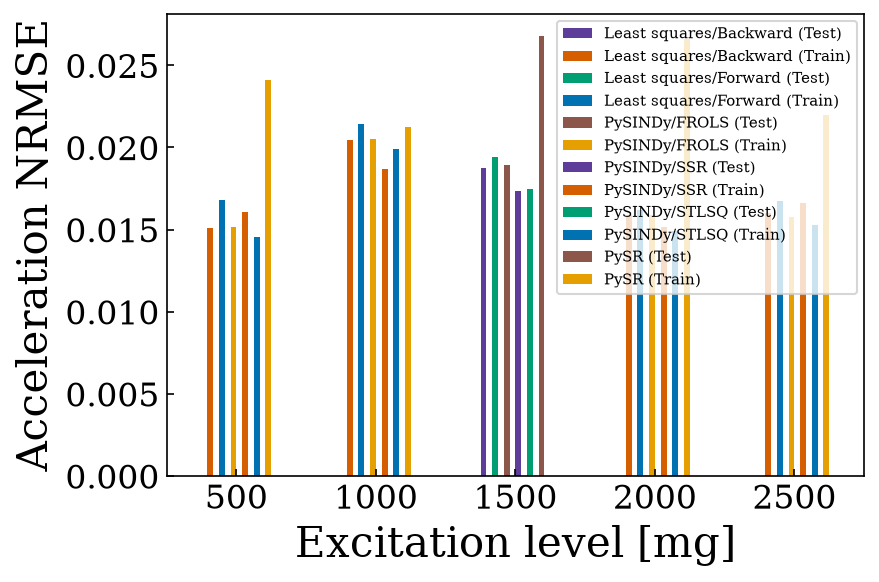

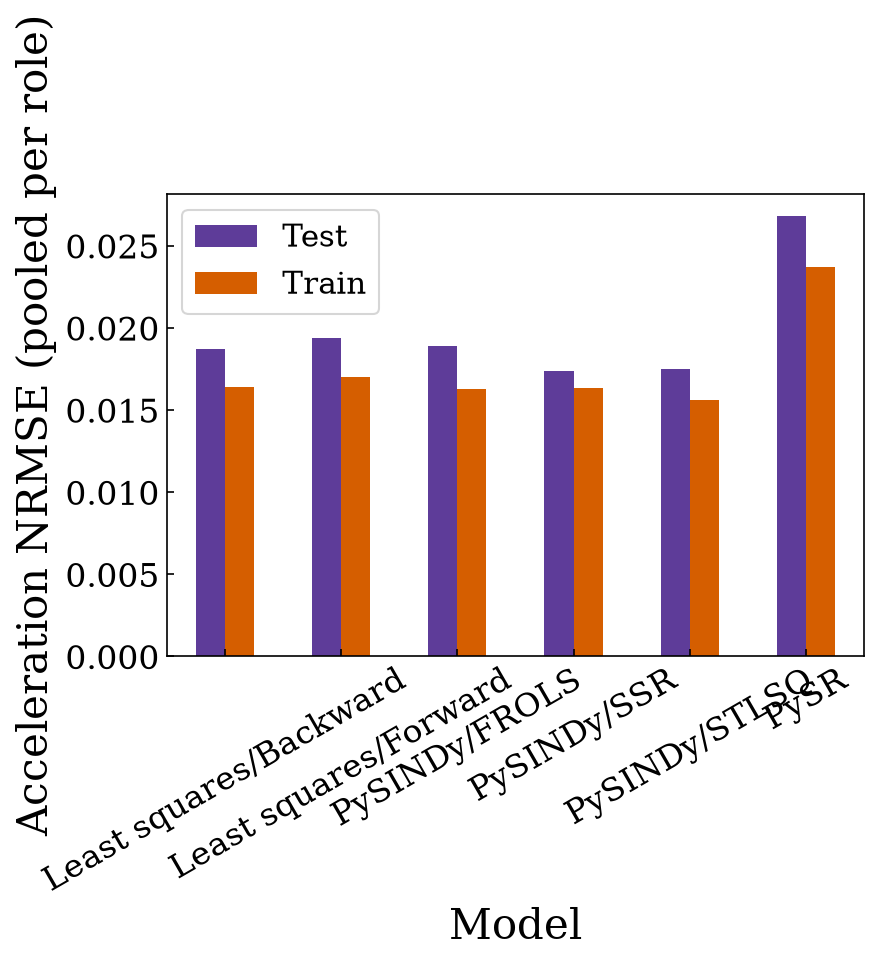

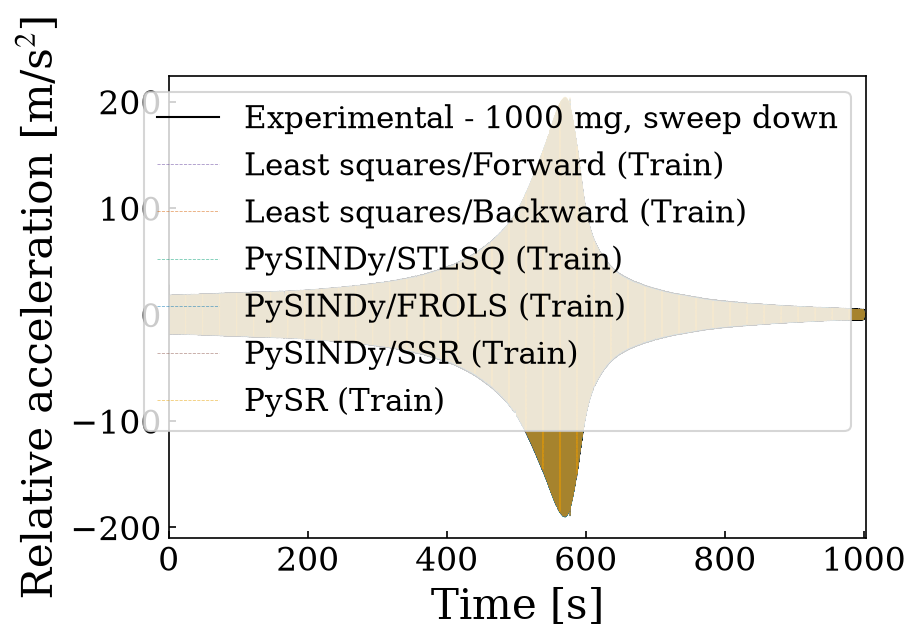

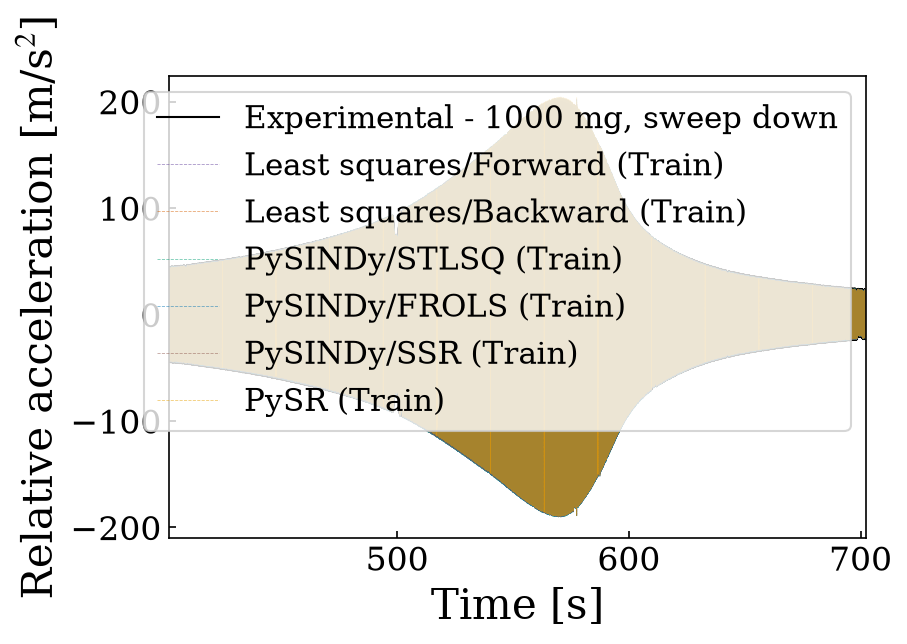

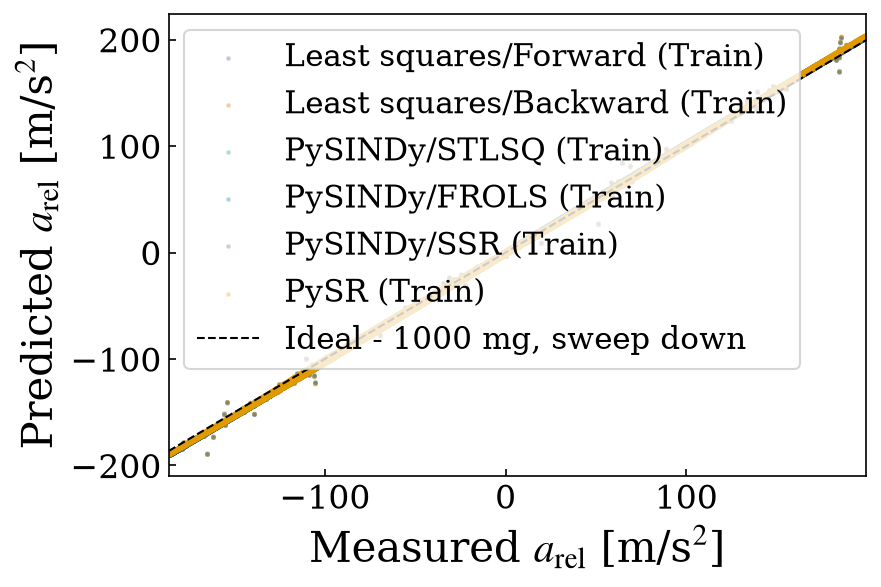

...

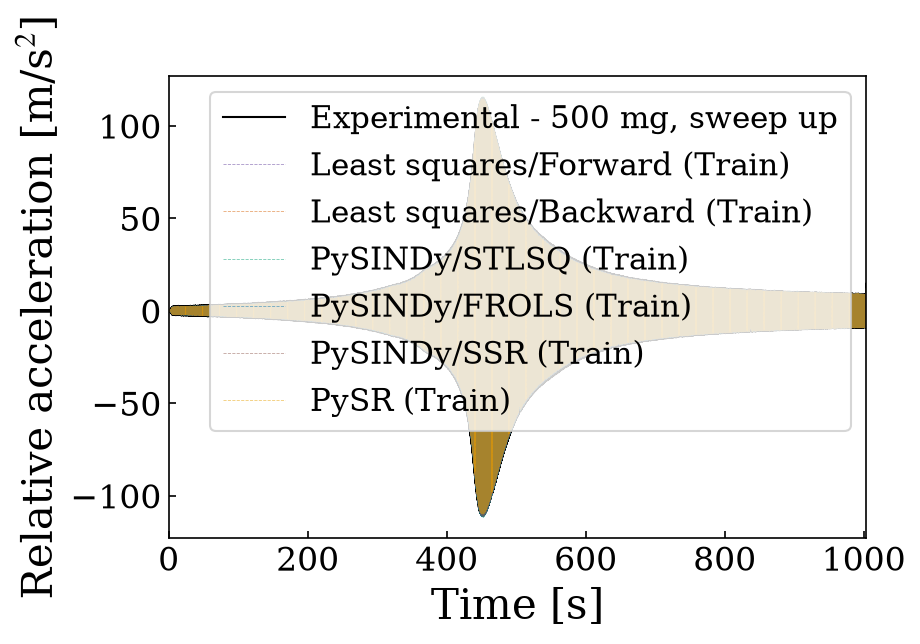

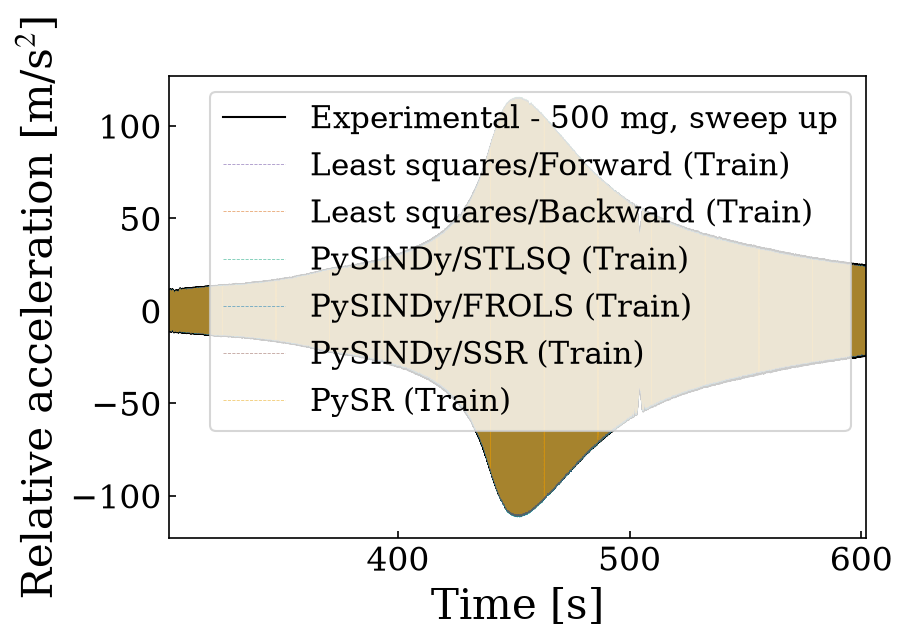

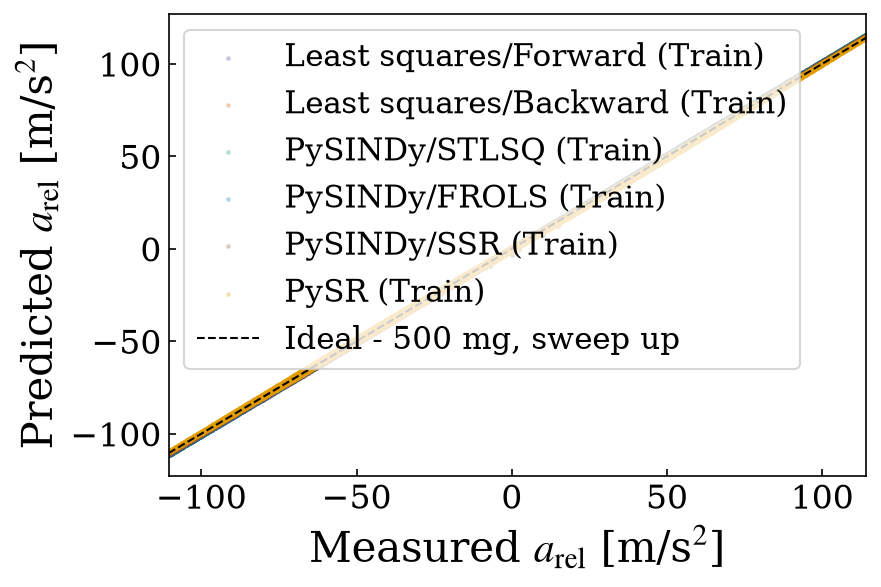

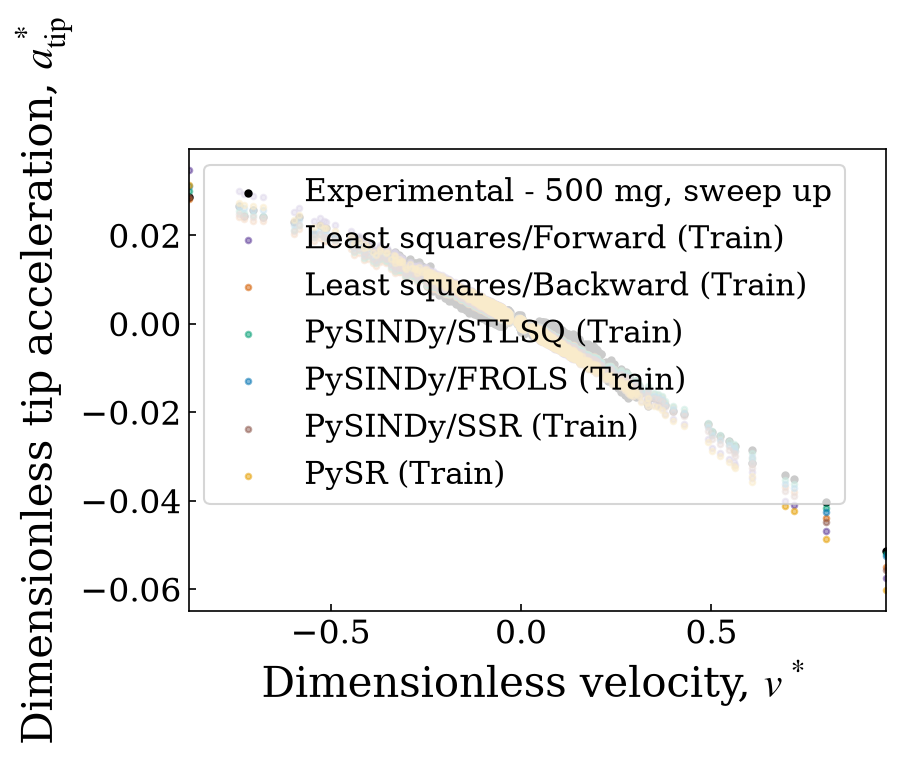

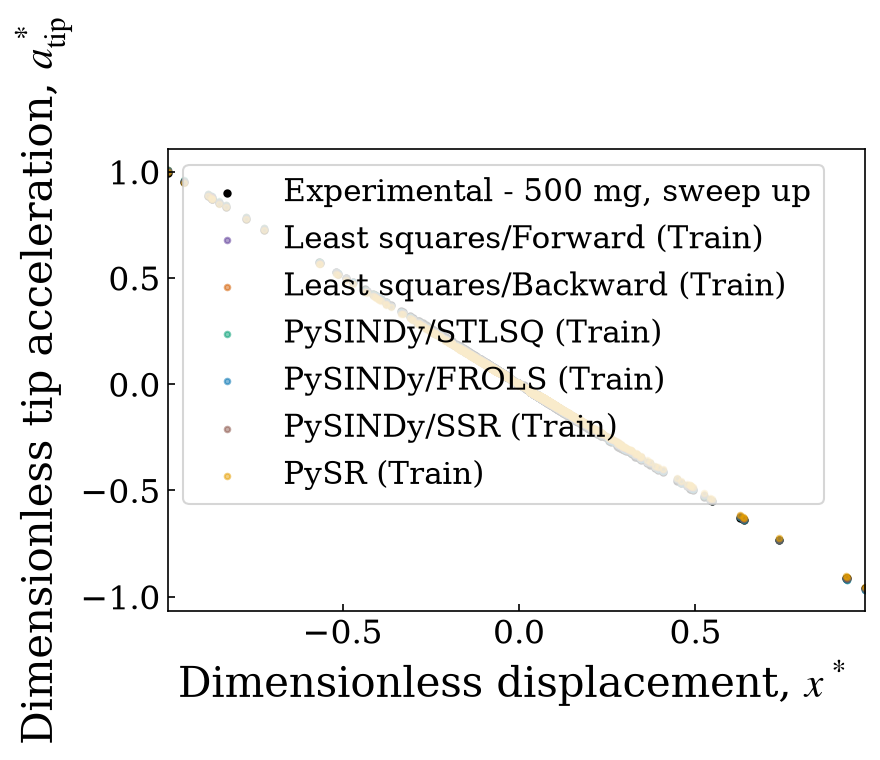

In [8]:
comparison_series = {}
for name in common_signals:
    record = dict(reference_series[name])
    record["model_predictions"] = {
        comparison_label(method, model): dict(MODEL_SERIES[method][name]["model_predictions"][model])
        for method, model in COMPARED_MODELS
    }
    comparison_series[name] = record

one_step_metrics, one_step_per_level, one_step_aggregate = summarize_models(comparison_series)
display(one_step_metrics)
display(one_step_per_level)
display(one_step_aggregate)
plot_level_metrics(one_step_per_level, "total_NRMSE", "Acceleration NRMSE", FIGURES_DIR / "one_step_level_metrics.pdf")
fig, ax = plt.subplots()
one_step_aggregate.pivot(index="model", columns="role", values="total_NRMSE").rename(columns=ROLE_LABELS).rename_axis(columns=None).plot.bar(ax=ax)
ax.set(xlabel="Model", ylabel="Acceleration NRMSE (pooled per role)")
ax.tick_params(axis="x", rotation=30)
fig.savefig(FIGURES_DIR / "one_step_role_metrics.pdf")
plt.show()
comparison_dimensionless_scales = plot_diagnostics(comparison_series, FIGURES_DIR)


### Test-level figures

Figures of the two 1500 mg sweeps, saved in their own folder.

**Test - 1500 mg**

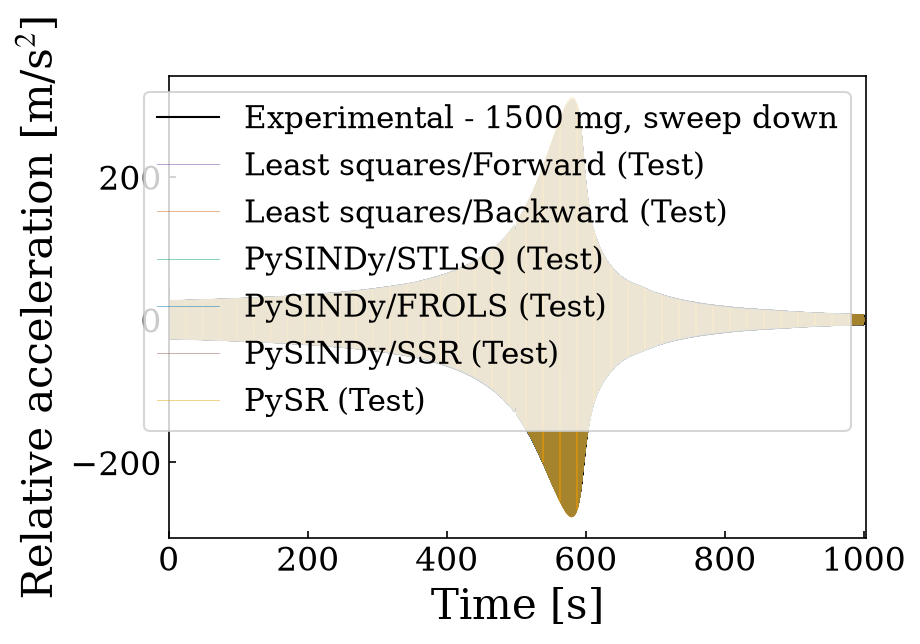

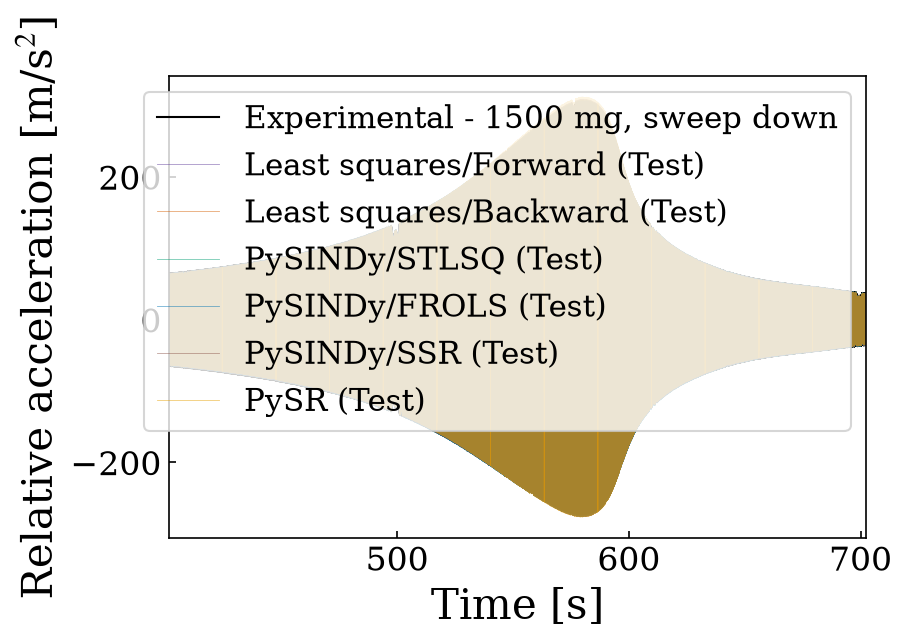

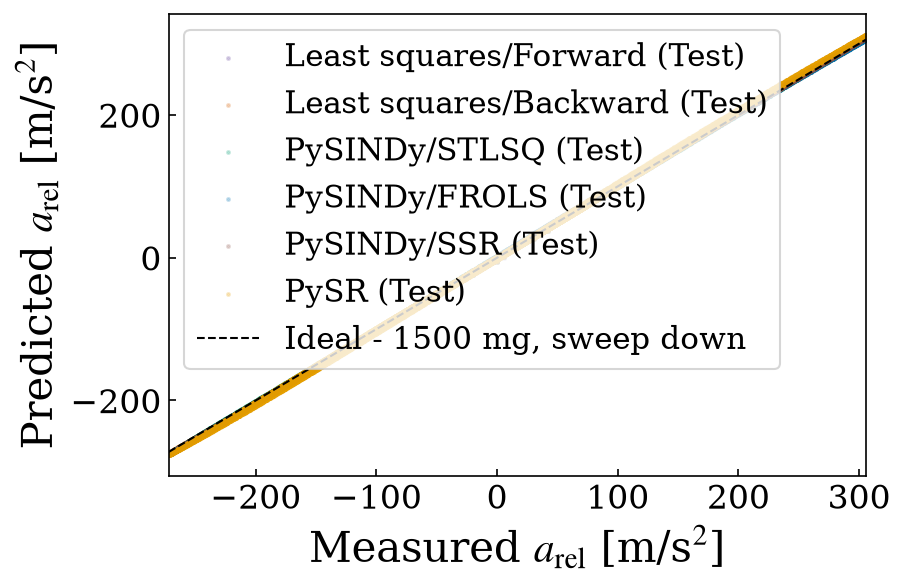

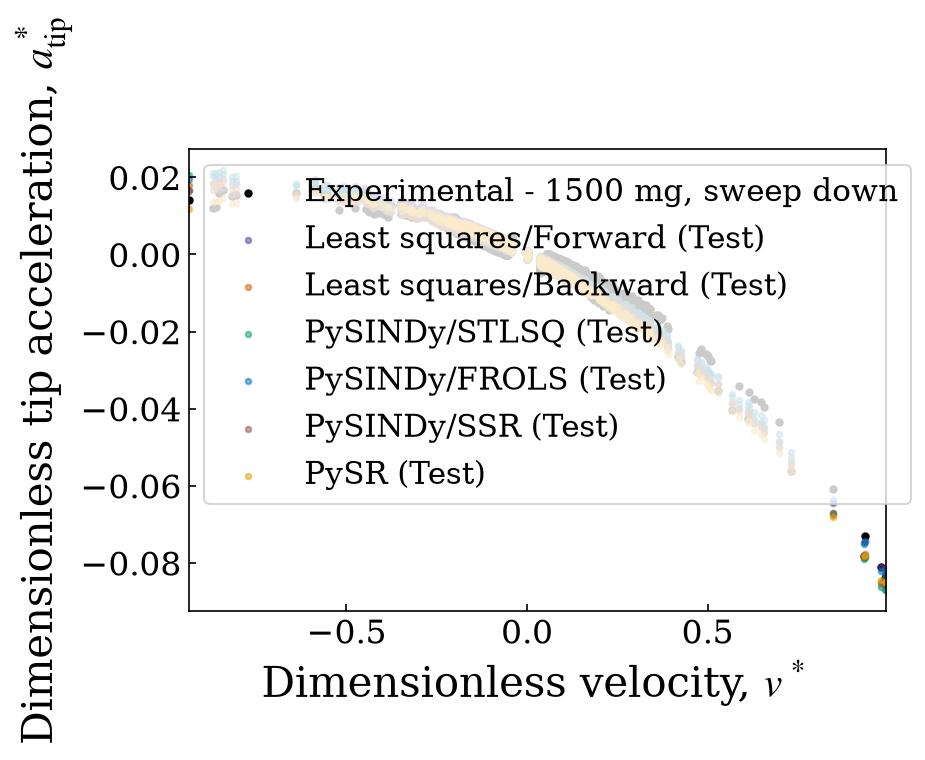

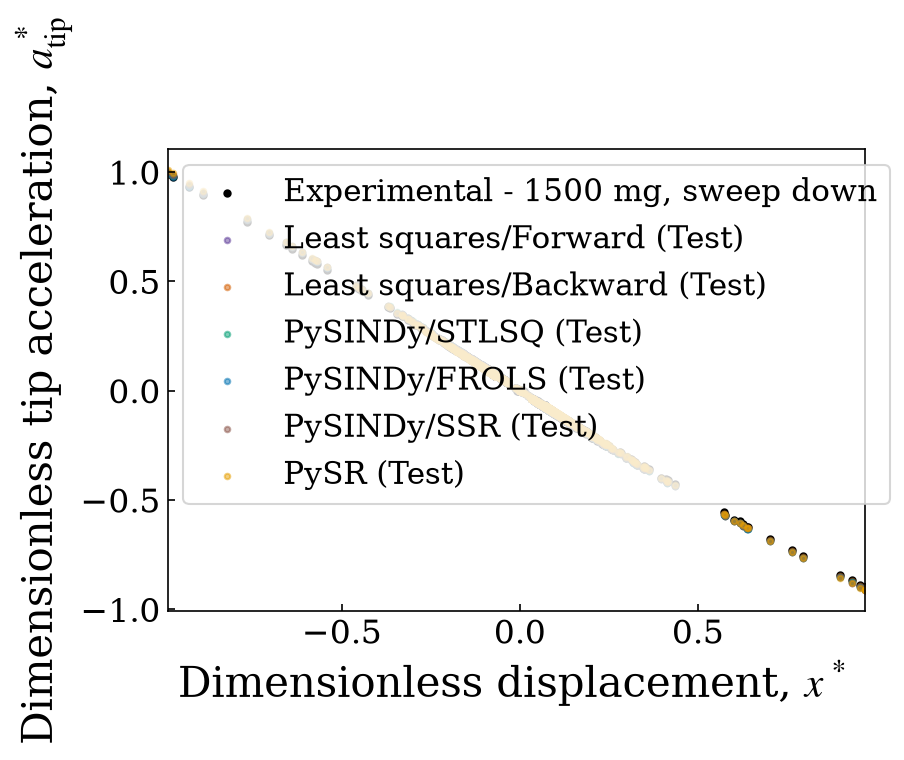

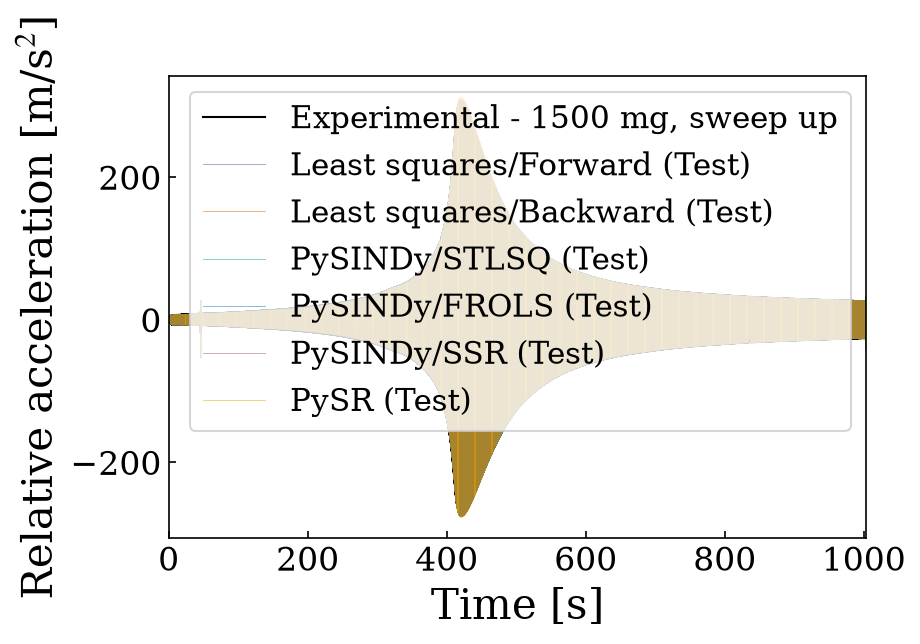

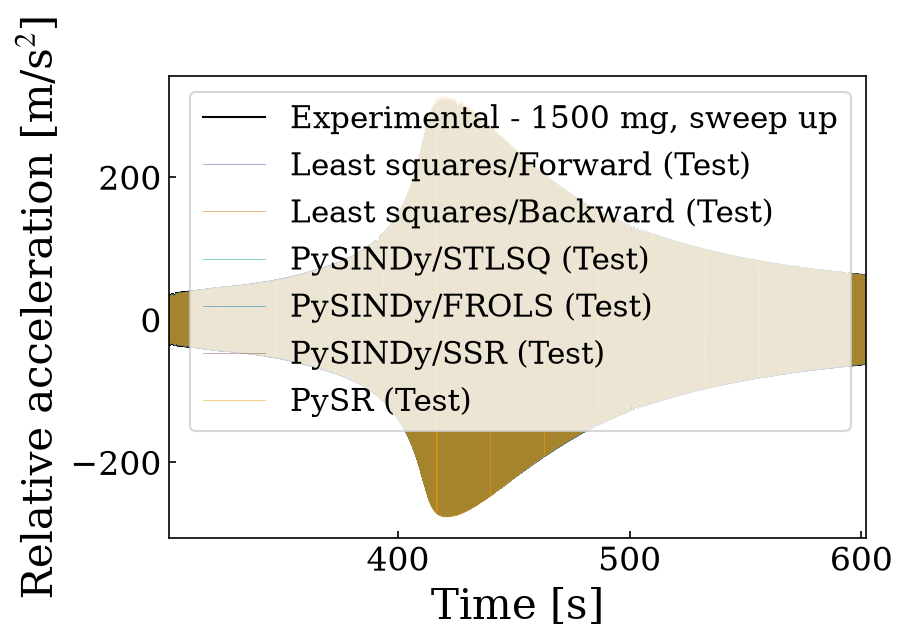

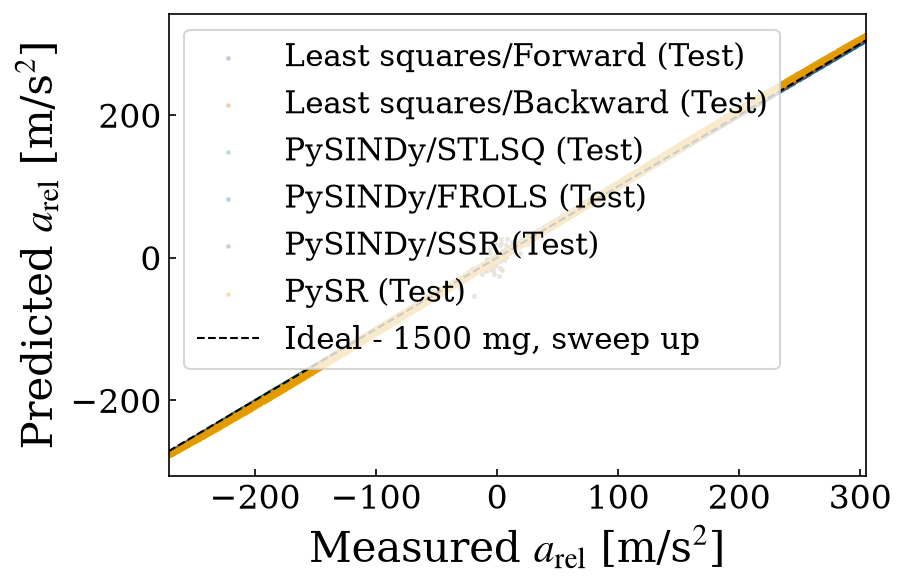

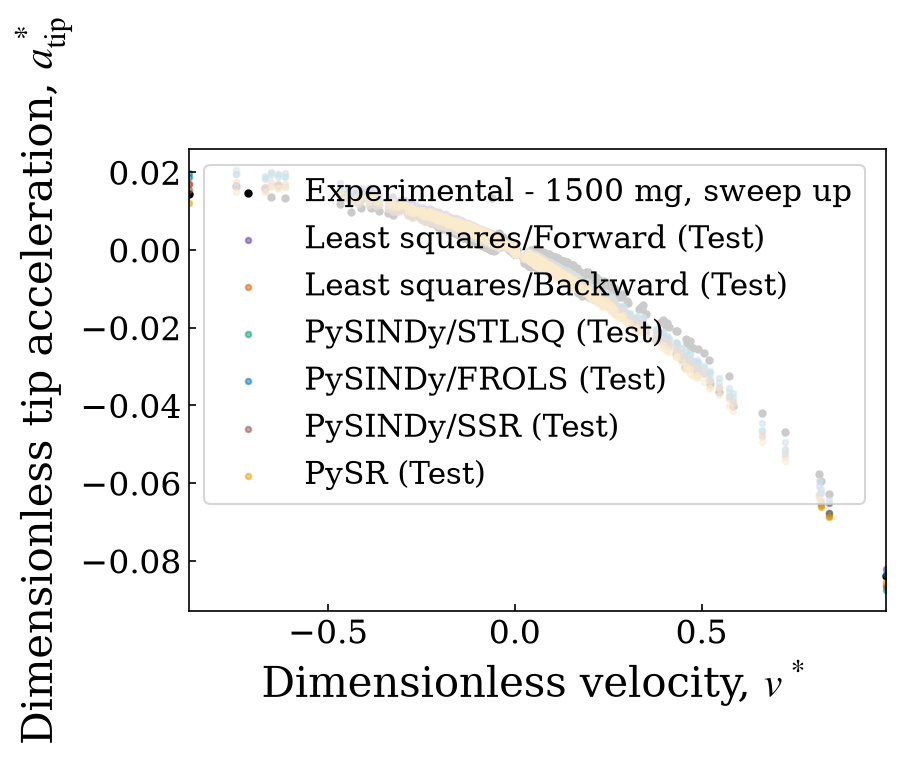

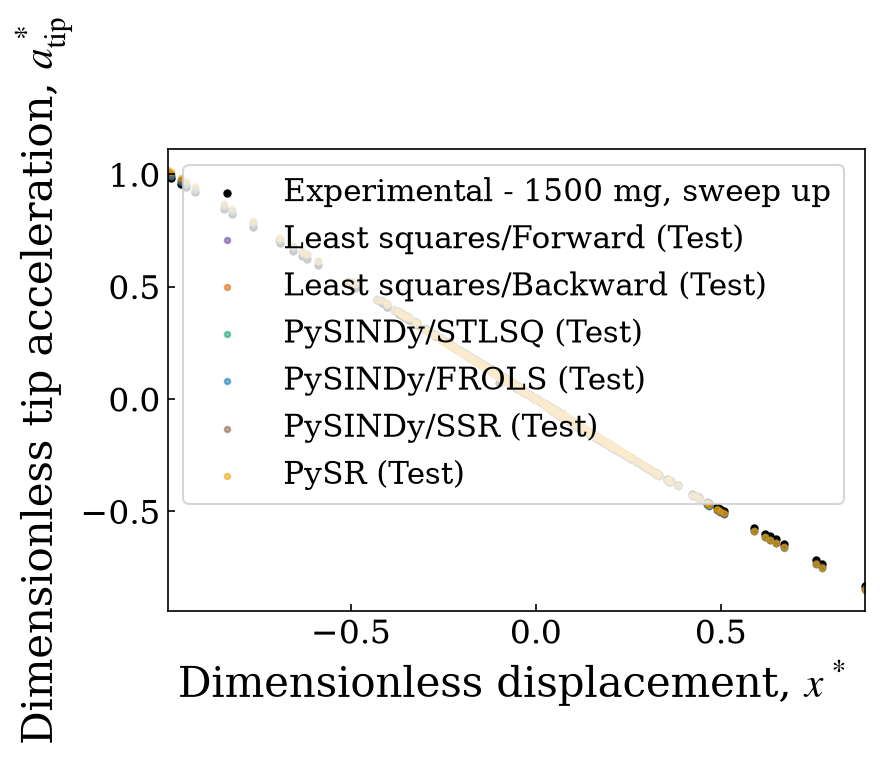

In [9]:
test_signals = [name for name in common_signals if comparison_series[name]["role"] == "test"]
if len(test_signals) != 2:
    raise ValueError(f"Expected one upward and one downward sweep at {TEST_LEVEL_MG} mg, found {test_signals}.")
display(Markdown(f"**Test - {TEST_LEVEL_MG} mg**"))
test_level_scales = plot_diagnostics(comparison_series, FIGURES_DIR / f"{TEST_LEVEL_MG}mg_test", names=test_signals)


### Experimental vs FROLS vs PySR

One-step and dimensionless figures with only the experimental data, PySINDy/FROLS and PySR, for every experiment. Saved in their own folder.

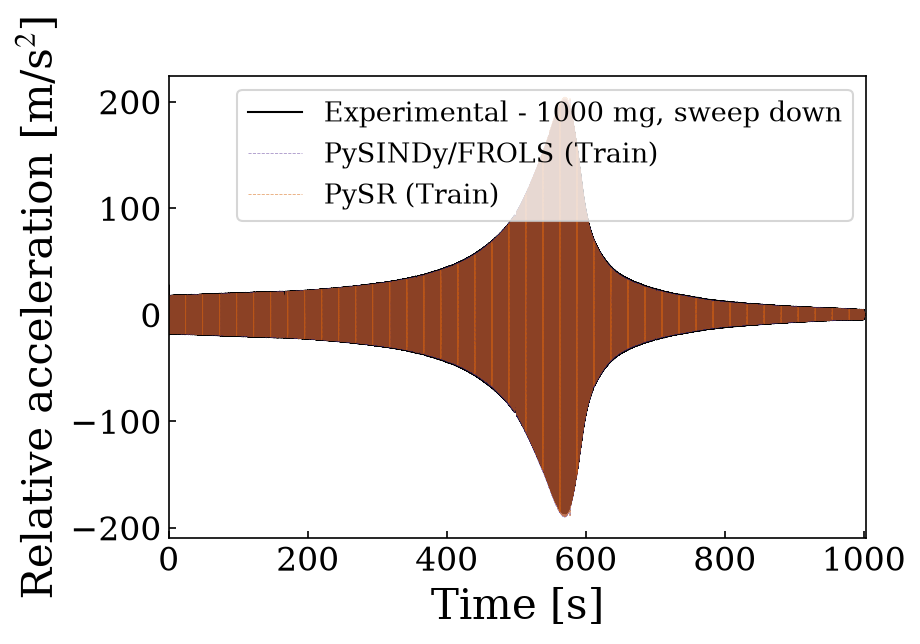

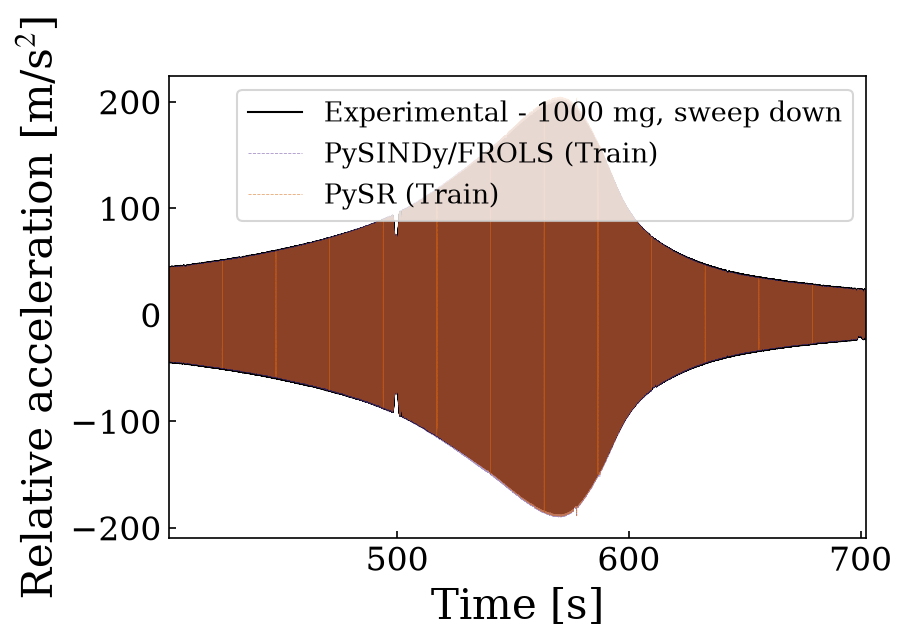

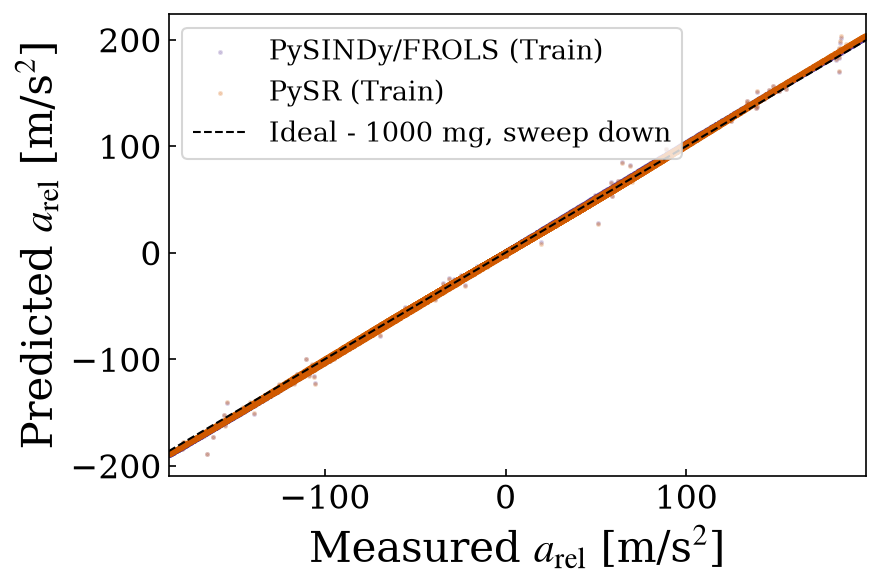

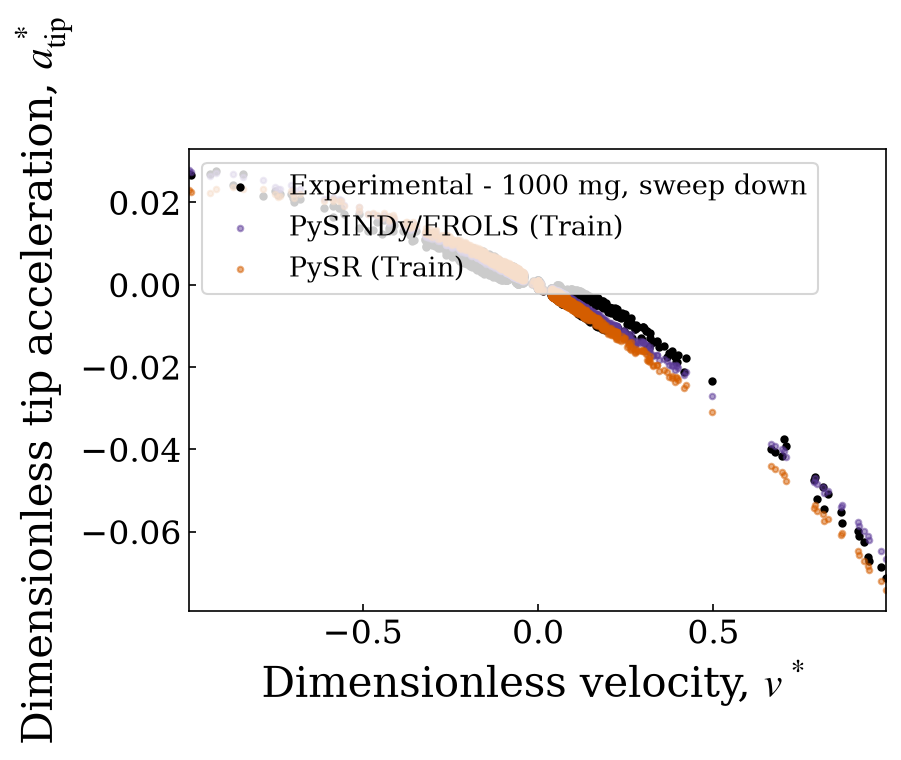

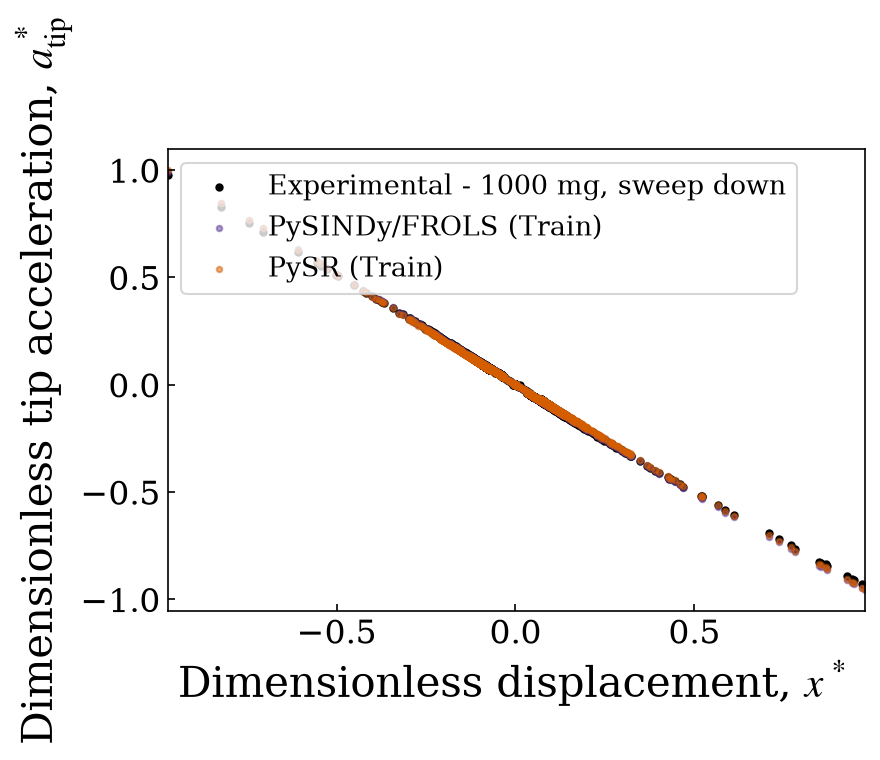

...

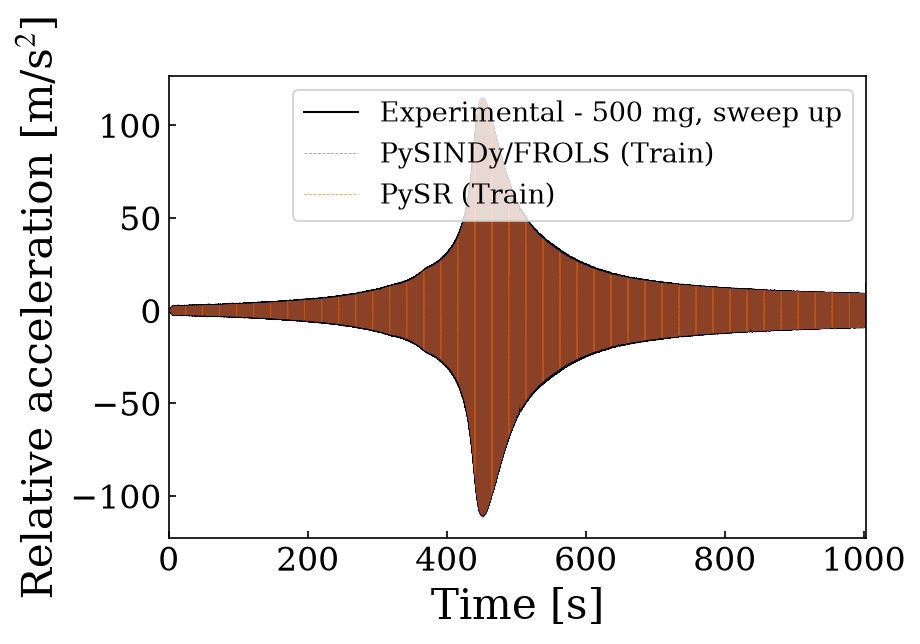

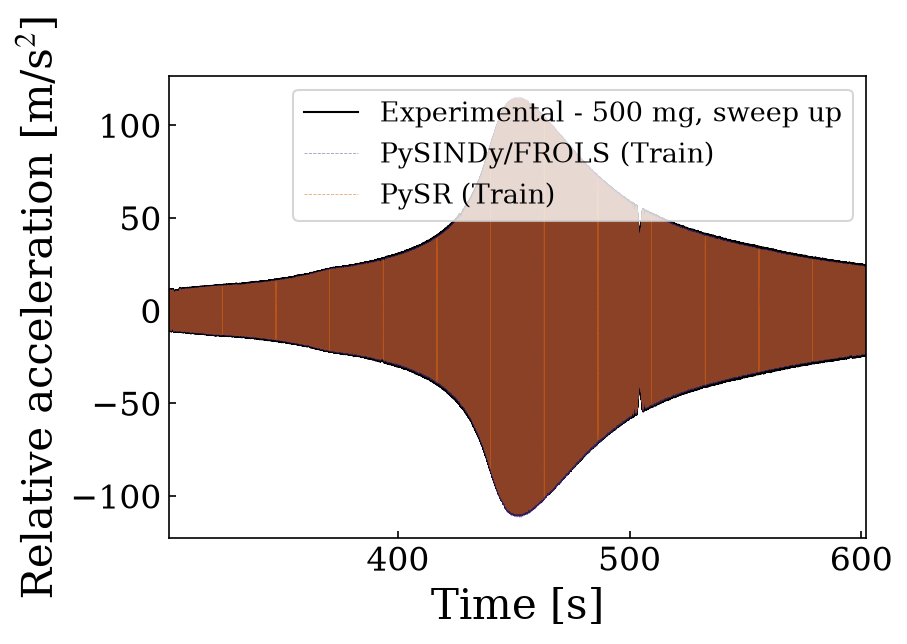

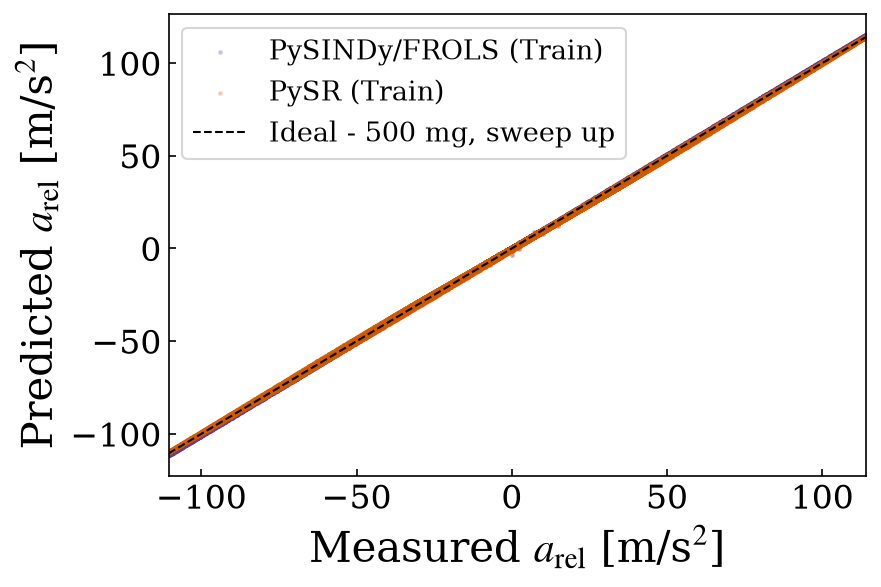

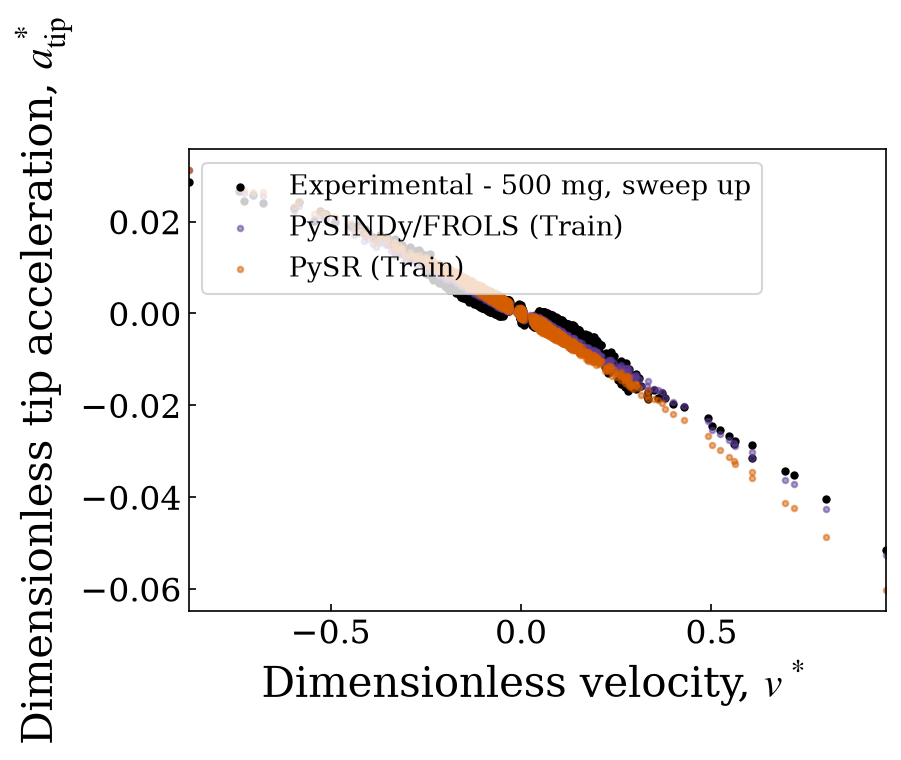

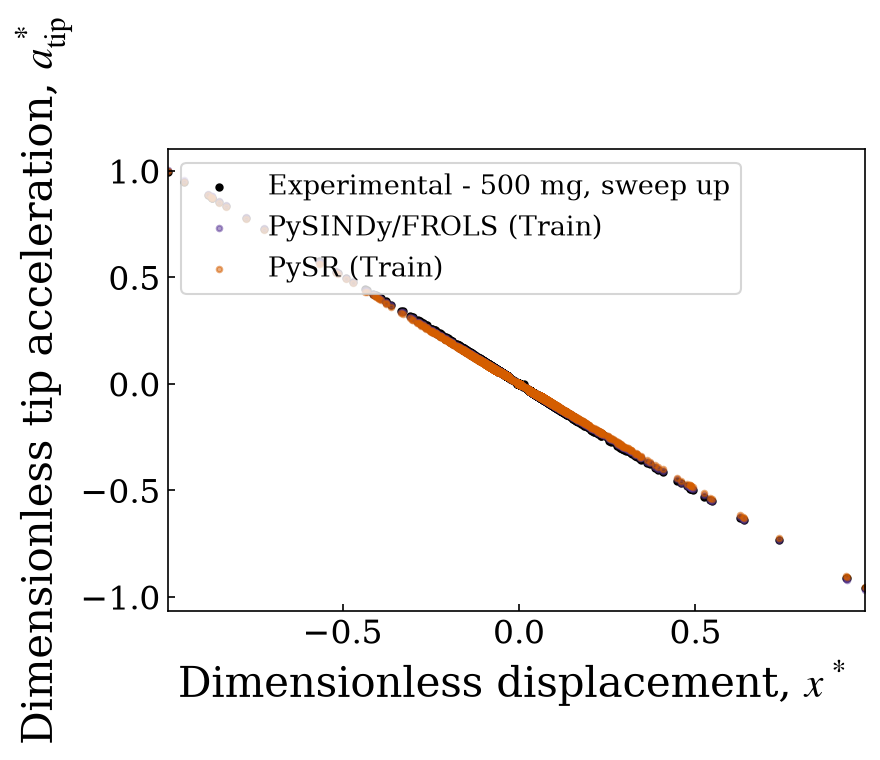

In [12]:
FROLS_PYSR_MODELS = [("PySINDy", "FROLS"), ("PySR", "PySR")]
frols_pysr_series = {}
for name in common_signals:
    record = dict(comparison_series[name])
    record["model_predictions"] = {
        comparison_label(method, model): comparison_series[name]["model_predictions"][comparison_label(method, model)]
        for method, model in FROLS_PYSR_MODELS
    }
    frols_pysr_series[name] = record
frols_pysr_scales = plot_diagnostics(frols_pysr_series, FIGURES_DIR / "frols_pysr")

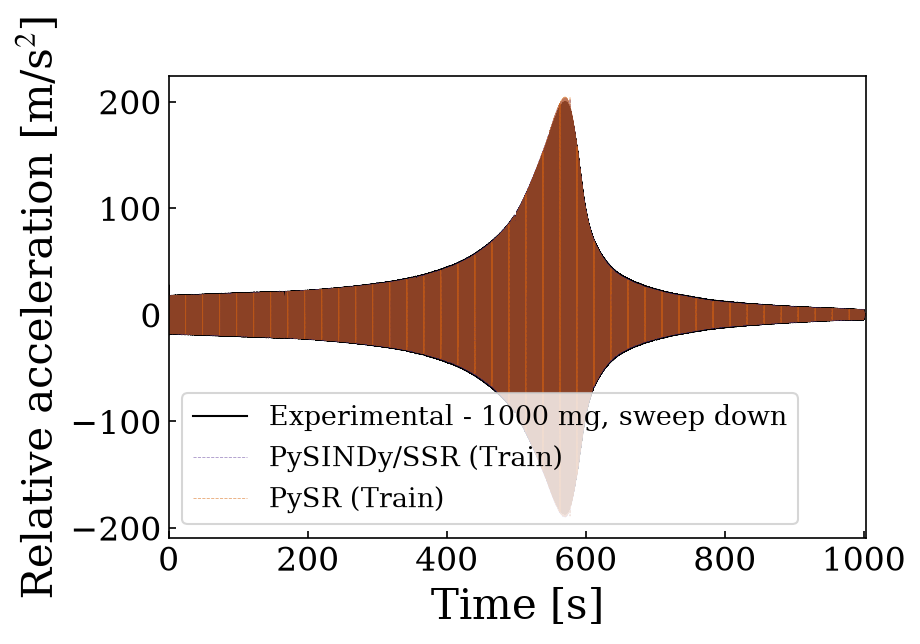

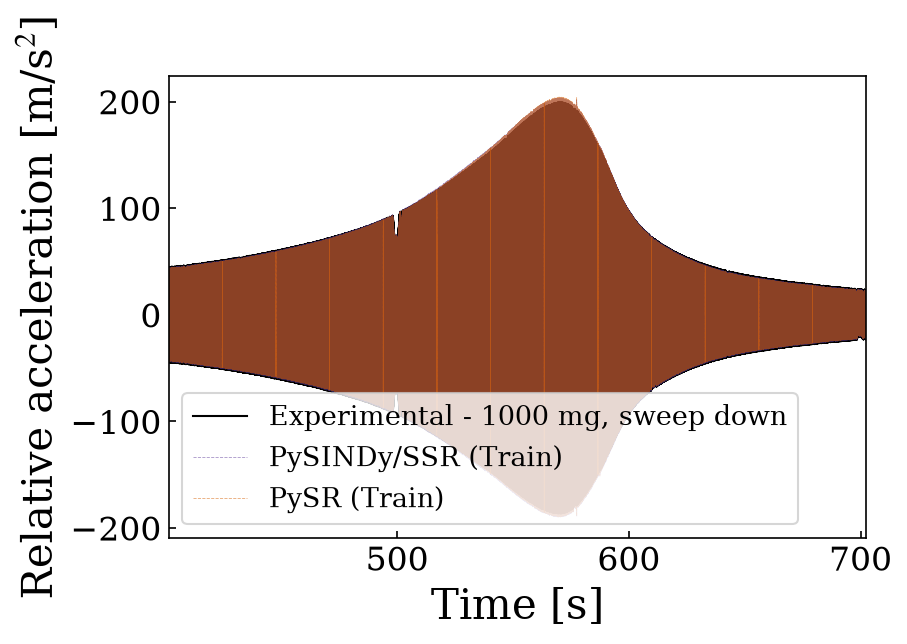

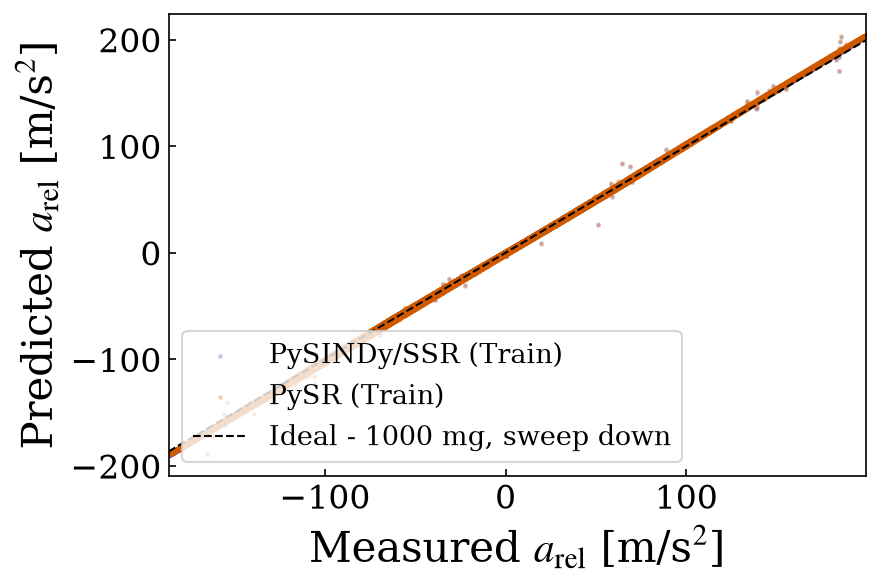

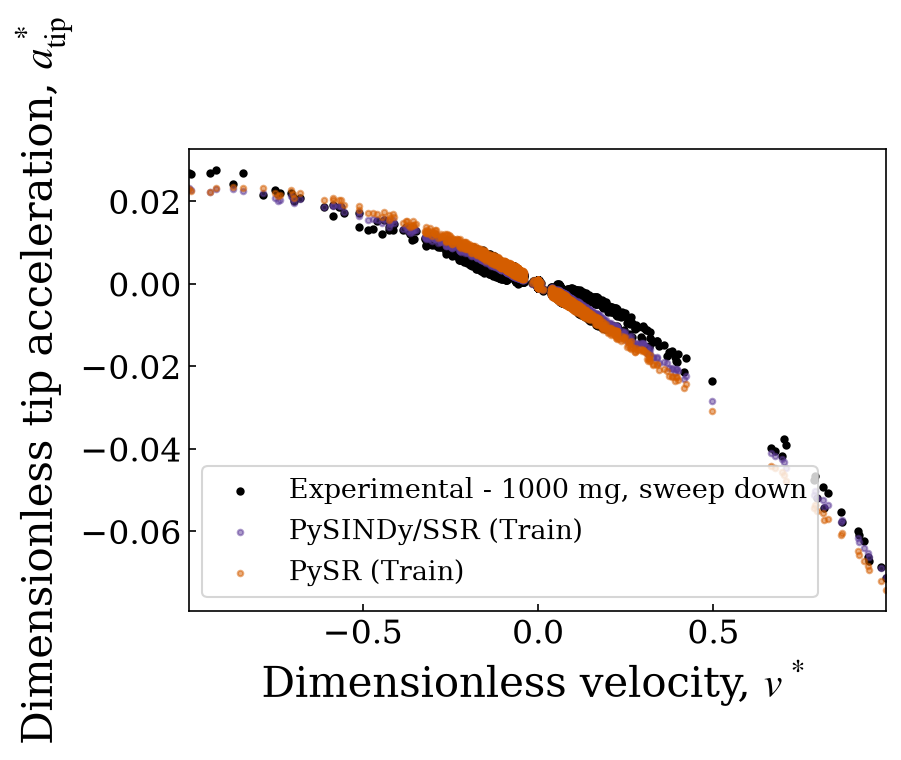

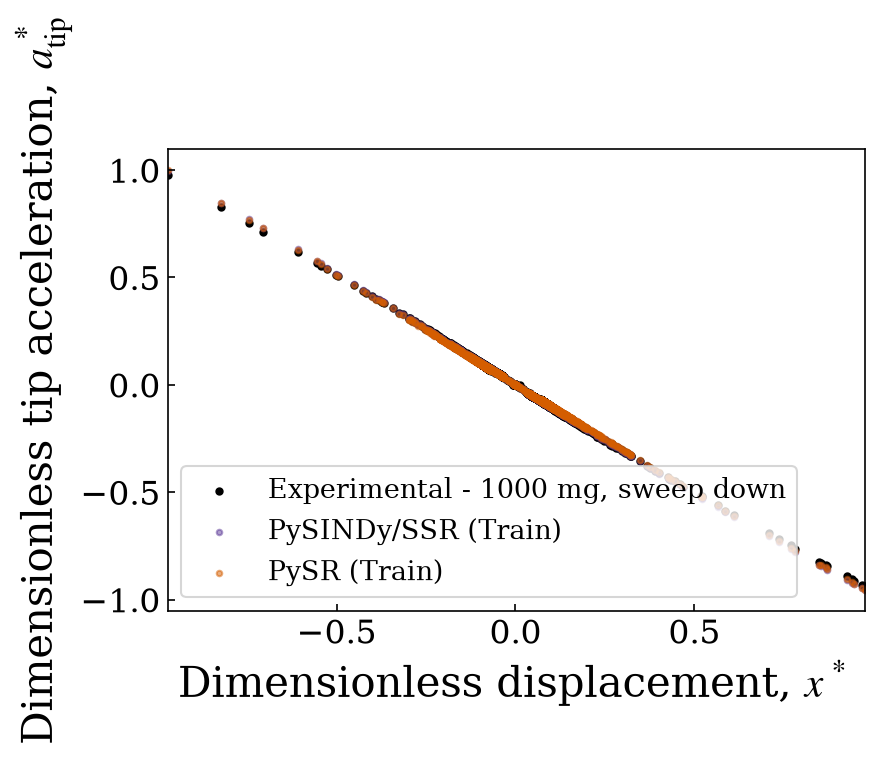

...

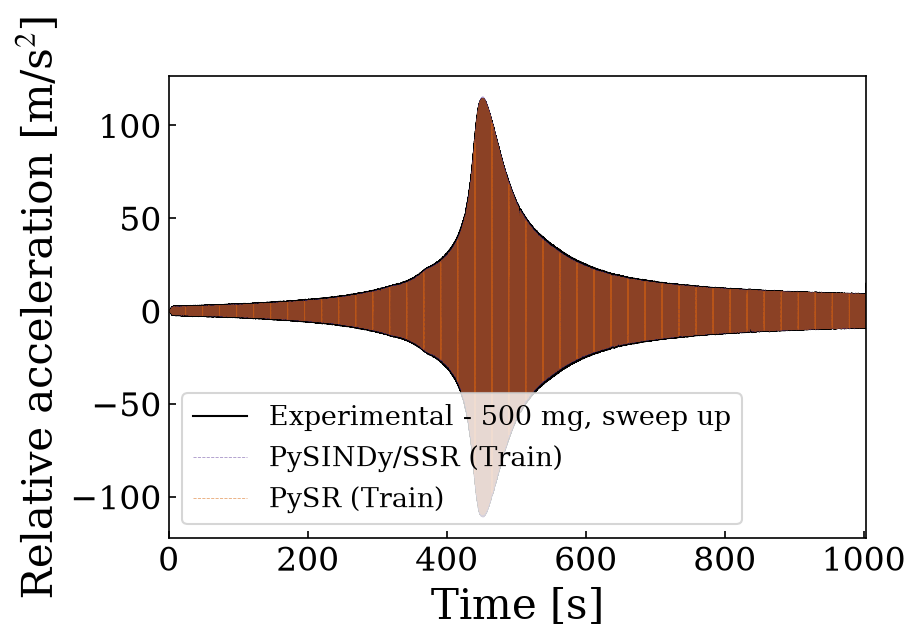

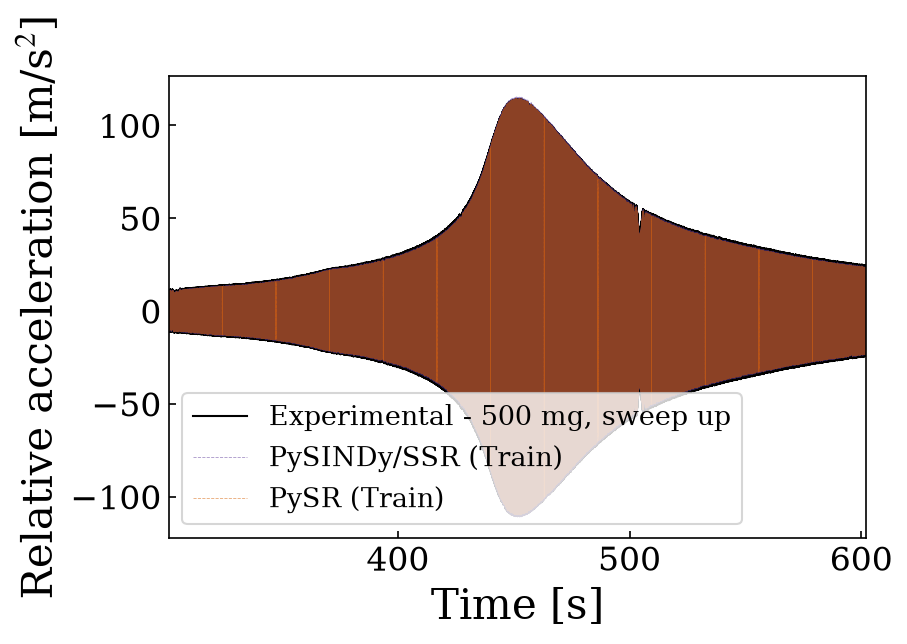

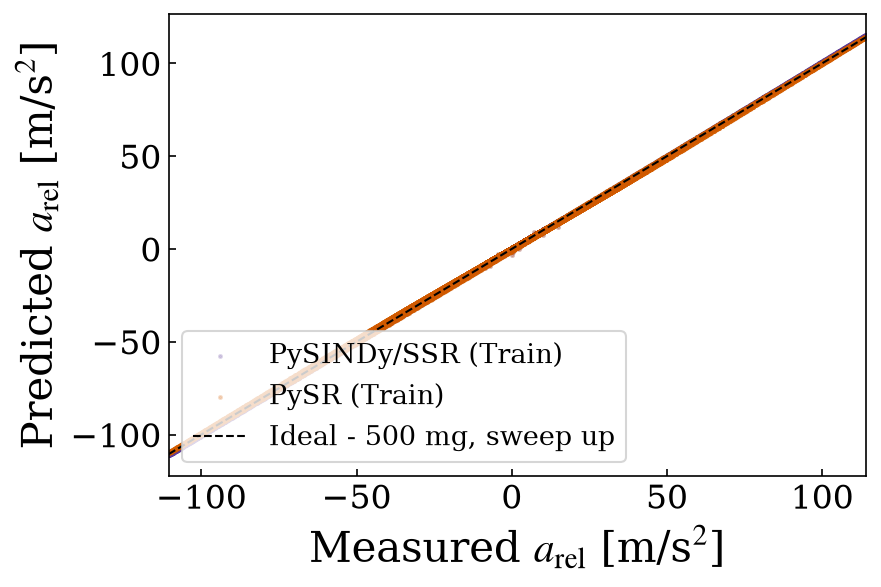

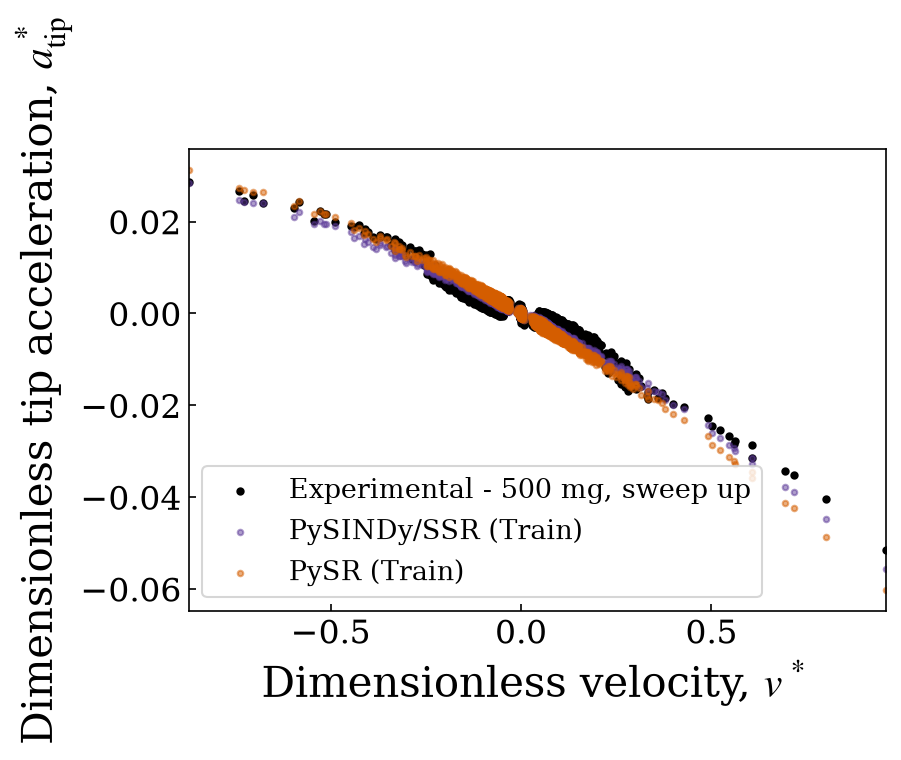

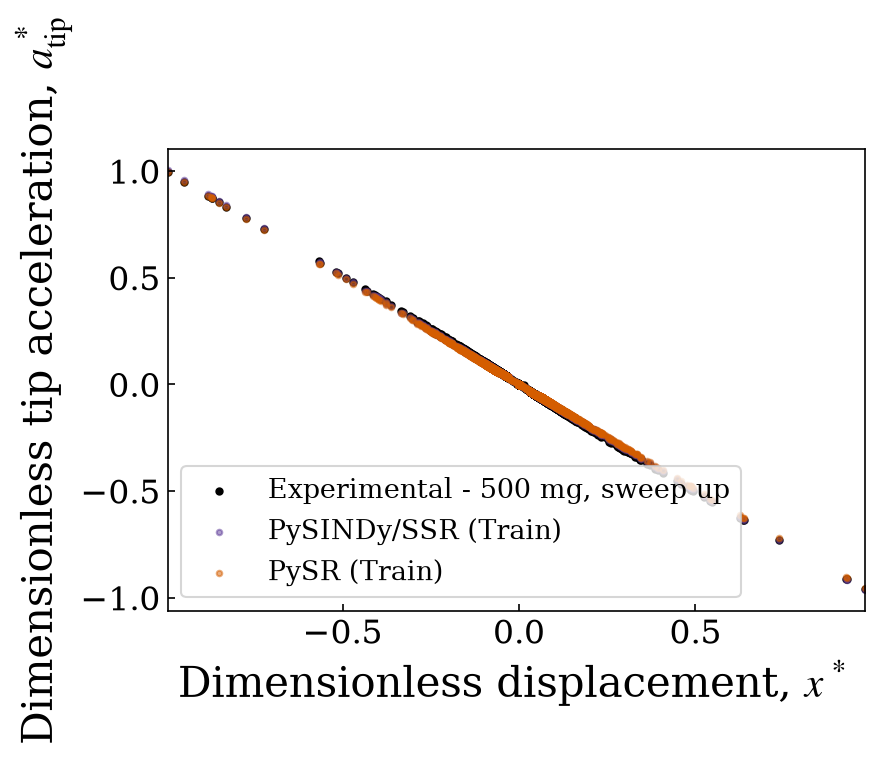

In [14]:
from unittest.mock import patch
from matplotlib.axes import Axes

SSR_PYSR_MODELS = [("PySINDy", "SSR"), ("PySR", "PySR")]

ssr_pysr_series = {}
for name in common_signals:
    record = dict(comparison_series[name])
    record["model_predictions"] = {
        comparison_label(method, model): comparison_series[name]["model_predictions"][
            comparison_label(method, model)
        ]
        for method, model in SSR_PYSR_MODELS
    }
    ssr_pysr_series[name] = record

# Altera a posição das legendas apenas durante esta chamada.
_original_legend = Axes.legend

def _legend_lower_left(self, *args, **kwargs):
    kwargs["loc"] = "lower left"
    return _original_legend(self, *args, **kwargs)

with patch.object(Axes, "legend", _legend_lower_left):
    ssr_pysr_scales = plot_diagnostics(
        ssr_pysr_series,
        FIGURES_DIR / "ssr_pysr",
    )

## Save comparison tables

In [ ]:
comparison_results = {
    "schema_version": 5,
    "source_files": {"least_squares": str(LEAST_SQUARES_RESULTS_FILE.resolve()),
                     "pysindy": str(PYSINDY_RESULTS_FILE.resolve()), "pysr": str(PYSR_RESULTS_FILE.resolve())},
    "compared_models": COMPARED_MODELS,
    "common_signals": common_signals,
    "protocol": pysindy_results["protocol"],
    "criteria": criteria_comparison,
    "weighting": weighting_comparison,
    "model_summary": model_summary,
    "one_step_metrics": one_step_metrics,
    "one_step_per_level": one_step_per_level,
    "one_step_aggregate": one_step_aggregate,
    "comparison_score_weights": {"total": TOTAL_ERROR_WEIGHT, "resonance": RESONANCE_ERROR_WEIGHT},
    "dimensionless_scales": comparison_dimensionless_scales,
}
comparison_file = RESULTS_DIR / "model_comparison.pkl"
with comparison_file.open("wb") as file:
    pickle.dump(comparison_results, file, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Saved: {comparison_file}")


Saved: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\model_comparison.pkl
